# Physics Beyond the Standard Model Notebook

#### David W. Barker

## Boiler Plate

In [1]:
### Boilerplate ###
## Boiler Plate that is required to run to make any cell below this work ##
# %matplotlib widget
# %matplotlib inline
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/dbarker7752/py21cmsig")
import py21cmsig
from pylinex import BasisSum, MetaFitter, AttributeQuantity, TrainedBasis, RepeatExpander, NullExpander, Forecaster, CompiledQuantity, \
    NLFitter,Sampler, LoadableModel
from tqdm import tqdm
import healpy as hp
from scipy import stats
from scipy.optimize import fsolve
from importlib import reload
import scipy
import perses
import copy
import os
import lmfit
from astropy.io import fits
from lmfit import Minimizer, Parameters, create_params, report_fit
import lochness
import perses.models
import camb
from pygdsm import GlobalSkyModel16
from pygdsm import GlobalSkyModel
from pylinex import TrainedBasis, SumModel,\
	BasisModel, SingleConditionalFitModel, ExpandedModel,\
	RepeatExpander, ConditionalFitGaussianLoglikelihood, \
	SlicedModel, GaussianLoglikelihood, LeastSquareFitter, Sampler,\
	BurnRule, NLFitter, TrainingSetCreator, ProjectedModel, Forecaster
from distpy import Expression, UniformConditionDistribution,\
	WindowedDistribution, DistributionList, DistributionSet,\
	UniformDistribution, GaussianDistribution, UniformConditionDistribution,\
    JumpingDistribution, JumpingDistributionSet, GaussianJumpingDistribution
import camb
from scipy.integrate import solve_ivp
import corner
from PIL import Image
import matplotlib.animation as animation
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
from datetime import datetime

parameter_variation_factor_perfect = 0.000000000005  # "PERFECT" sytematics

# universal variables
frequencies = np.arange(5,50)
true_lusee_frequencies = np.arange(0.1,50,0.04875)

location = (-23.815,182.25)  # The lat lon location of the moon landing site
spice_kernels = "/home/dbarker7752/lochness/input/spice_kernels/" #location of the spice kernels

# Some basic constants
kb = 1.3807e-16    # Boltzman's constant [ergs per Kelvin]
kb_ev = 8.617e-5   # Boltzman's constant [electron volts per Kelvin]
h_pl = 6.6260755e-27 # Planck's constant [erg seconds]
c = 3e10        # speed of light [cm/s]
# Parameters  (Taking the Lambda CDM ones from Planck collaboration 2020 pg.19 (without BAO because of no real reason))
H0 = 67.49 # Hubble constant 
h = H0/100     # H0
omM0h2 = 0.1430
omB0h2 = 0.02237
omC0h2 = 0.1200  # Omega cold dark matter today 
omM0 = 0.1430/h**2   # Omega matter today
omB0 = 0.02237/h**2   # Omega baryons today 
omK0 = 0        # Omega curvature today
# omC0 = 0.1200/h**2   # Omega cold dark matter today 
omC0 = omM0-omB0
#omR0 = 8.98e-5  # Omega radiation today
omR0=8.600000001024455e-05  # Omega radiation from 21cm FAST
omL0 = 0.6847   # Omega Dark Energy today
f_He = 0.08    # Fraction of Helium by number
y_P = 0.2454  # Fraction of helium by mass (from Planck VI 2018) 
p_crit = 1.88e-29*h**2  # [g/cm^3] The critical density of the universe
p_crit_ergs = p_crit*8.99e20  #[ergs/cm^3]
m_p = 1.6727e-24   #[g]  mass of a proton
m_pMev = 938.28   # [MeV/c^2] mass of a proton
m_e = 9.1094e-28   #[g]  mass of an electron
m_eMev = 0.511      # [Mev/c^2] mass of an electron
m_He = 6.644e-24   # [g] mass of helium
fsc = 1/137        # dimensionless fine structure constant
z_array = np.arange(20,1100)
#n_b0 = 2.06e-7   #[baryons per cubic centimeter] Old version from Joshua's comps paper that isn't a function of Omega baryons
n_b0 = (1-y_P)*omB0*p_crit/m_p+y_P*omB0*p_crit/m_He  # number density of baryons (by definition doesn't include electrons)
T_gamma0 = 2.725   # [Kelvin] modern CMB temperature
T_star = 0.068    # [Kelvin] the temperature equivalent of the energy difference of the 21 cm hyperfine spin states
A_10 = 2.85e-15    # [inverse seconds] Einstein coefficient for the spontaneous emission of the hyperfine spin states
# Less neccesary (or at least less understood by me but needed by some code)
As = 2.099e-9  # Amplitude of a power spectrum of adiabatic perturbations
ns = 0.9649    # Spectra index of a power spectrum of adiabatic perturbations

# sigma for cosmological parameters derived from Planck
omM0sigma = 0.0011/h**2
omL0sigma = 0.0062
omB0sigma = 0.00014/h**2

omM0h2sigma = 0.0011
omB0h2sigma = 0.00014

fiducial_signal = perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)([omM0h2,omB0h2])

overlap = lambda u, v: np.abs(np.dot(u, v) /(np.linalg.norm(u) * np.linalg.norm(v)))

### Common equations:
H = lambda z,omR0,omM0,omK0,omL0,H0: (H0*3.24078e-20)*(1+z)*np.sqrt(omR0*(1+z)**2+omM0*(1+z)+omK0+(omL0/((1+z)**2)))  # Standard Lambda CDM hubble flow in inverse seconds
T_gamma = lambda z: T_gamma0*(1+z)
#dTb = lambda z,x_e,T_k,omB0h2,omM0h2: 27*(1-x_e(z))*((omB0h2)/(0.023))*(((0.15)/(omM0h2))*((1+z)/(10)))**(1/2)*(1-((T_gamma0*(1+z))/(T_S(z,x_e,T_k))))
dTb = lambda z,x_e,T_k,omB0,omM0: 27*(1-x_e(z))*((h**2*omB0)/(0.023))*(((0.15)/(h**2*omM0))*((1+z)/(10)))**(1/2)*(1-((T_gamma0*(1+z))/(T_S(z,x_e,T_k))))
# Synchrotron Equation
synch = lambda f,A,B,c : A*(f/408)**(B+c*np.log(f/408))  # taken from page 6 of Hibbard et al. 2023 Apj. Arbitrarily chose 25 as my v0

k_HH_raw = np.array([[1,1.38e-13],[2,1.43e-13],[4,2.71e-13],[6,6.60e-13],[8,1.47e-12],[10,2.88e-12],[15,9.10e-12],[20,1.78e-11],[25,2.73e-11],[30,3.67e-11],[40,5.38e-11],[50,6.86e-11],[60,8.14e-11],[70,9.25e-11],\
                 [80,1.02e-10],[90,1.11e-10],[100,1.19e-10],[200,1.75e-10],[300,2.09e-10],[500,2.56e-10],[700,2.91e-10],[1000,3.31e-10],[2000,4.27e-10],[3000,4.97e-10],[5000,6.03e-10]])
k_eH_raw = np.array([[1, 2.39e-10],[2,3.37e-10],[5,5.30e-10],[10,7.46e-10],[20,1.05e-9],[50,1.63e-9],[100,2.26e-9],[200,3.11e-9],[500,4.59e-9],[1000,5.92e-9],[2000,7.15e-9],[3000,7.71e-9],[5000,8.17e-9]])

# let's write a function that interpolates this table given whatever value we put in.
k_HH = scipy.interpolate.CubicSpline(k_HH_raw.transpose()[0],k_HH_raw.transpose()[1])   # Needs a temperature (or array of temps) as an argument
k_eH = scipy.interpolate.CubicSpline(k_eH_raw.transpose()[0],k_eH_raw.transpose()[1])   # Needs a temperature (or array of temps) as an argument

## n_H and n_e

n_H = lambda z,x_e: n_b0*(1+z)**3*(1-x_e(z))
n_e = lambda z,x_e: n_b0*(1+z)**3*(x_e(z))
n_tot = lambda z: n_b0*(1+z)**3

# x_c
x_c = lambda z,x_e,T_k: (T_star)/(T_gamma0*(1+z)*A_10)*(n_H(z,x_e)*k_HH(T_k(z))+n_e(z,x_e)*k_eH(T_k(z)))   # HH and eH

# T_S
T_S = lambda z,x_e,T_k: (1+x_c(z,x_e,T_k))/((1/(T_gamma0*(1+z)))+(x_c(z,x_e,T_k)/T_k(z)))

# x_e using camb
parameters_camb = camb.set_params(H0=H0, ombh2=omB0*h**2, omch2=omC0*h**2, As=As, ns=ns)
camb_data= camb.get_background(parameters_camb)
camb_xe = camb_data.get_background_redshift_evolution(z_array, ["x_e"], format="array")
# or if you want an interpolated version:
camb_xe_interp = scipy.interpolate.CubicSpline(z_array,camb_xe.flatten())  # Needs a redshift argument


# example simulation with fiducial signal
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/example_simulated_data_fiducial","r")
sim_data = np.array(hdf5["simulation"])
sim_data_signal = np.array(hdf5["signal"])
sim_data_no_noise = np.array(hdf5["simulation_no_noise"])
sim_data_noise_function = np.array(hdf5["noise_function"])

# radiometer noise
sigT = lambda T_b, N, dnu, dt: T_b/((np.sqrt(N*dnu*dt)))
N_antenna = 1
dnu = 1e6
dt = 100*3600
noise_level = sigT(sim_data,N_antenna,dnu,dt)

# 32 bit ULSA foreground
ULSA_direction_raw_32 = fits.open("/home/dbarker7752/py21cmsig/ULSA Maps/000.fits")
# This identifies the pixels of the dead zone
vec = hp.ang2vec(np.pi/2*1.1, -np.pi/2*1.05)
indices=hp.query_disc(nside=32,vec=vec,radius=0.2)
hole_map = copy.deepcopy(ULSA_direction_raw_32[0].data[7])
hole_map[indices] = 10000000
# These indices will be our region 10 which is the region we ignore
indices_deadzone = indices

# 32 bit ULSA foreground deadzone removal
x = np.arange(hp.nside2npix(32))
x = np.delete(x,indices_deadzone) # Gets rid of the dead zone
ULSA_min_deadzone = copy.deepcopy(ULSA_direction_raw_32[0].data)
for i,data in enumerate(ULSA_direction_raw_32[0].data):
    y = data
    y = np.delete(y,indices_deadzone)
    interpolator = scipy.interpolate.CubicSpline(x,y)
    for j in indices_deadzone:
        ULSA_min_deadzone[i][j] = interpolator(j)
ULSA_direction_32 = ULSA_min_deadzone

ULSA_direction_raw_64 = fits.open("/home/dbarker7752/py21cmsig/ULSA Maps/100.fits")
# This identifies the pixels of the dead zone
vec = hp.ang2vec(np.pi/2*1.1, -np.pi/2*1.05)
indices=hp.query_disc(nside=64,vec=vec,radius=0.1954)
hole_map = copy.deepcopy(ULSA_direction_raw_64[0].data[7])
hole_map[indices] = 10000000
# hp.mollview(ULSA_direction_raw_64[0].data[7])
# These indices will be our region 10 which is the region we ignore
indices_deadzone = indices

# 64 bit ULSA foreground deadzone removal
x = np.arange(hp.nside2npix(64))
x = np.delete(x,indices_deadzone) # Gets rid of the dead zone
ULSA_min_deadzone = copy.deepcopy(ULSA_direction_raw_64[0].data)
for i,data in enumerate(ULSA_direction_raw_64[0].data):
    y = data
    y = np.delete(y,indices_deadzone)
    interpolator = scipy.interpolate.CubicSpline(x,y)
    for j in indices_deadzone:
        ULSA_min_deadzone[i][j] = interpolator(j)
ULSA_direction_64 = ULSA_min_deadzone

# 128 bit ULSA foreground
ULSA_direction_raw_128 = fits.open("/home/dbarker7752/py21cmsig/ULSA Maps/200.fits")
# This identifies the pixels of the dead zone
vec = hp.ang2vec(np.pi/2*1.1, -np.pi/2*1.05)
indices=hp.query_disc(nside=128,vec=vec,radius=0.21)
hole_map = copy.deepcopy(ULSA_direction_raw_128[0].data[7])
hole_map[indices] = 10000000
# These indices will be our region 10 which is the region we ignore
indices_deadzone = indices

# 128 bit ULSA foreground deadzone removal
x = np.arange(hp.nside2npix(128))
x = np.delete(x,indices_deadzone) # Gets rid of the dead zone
ULSA_min_deadzone = copy.deepcopy(ULSA_direction_raw_128[0].data)
for i,data in enumerate(ULSA_direction_raw_128[0].data):
    y = data
    y = np.delete(y,indices_deadzone)
    interpolator = scipy.interpolate.CubicSpline(x,y)
    for j in indices_deadzone:
        ULSA_min_deadzone[i][j] = interpolator(j)
ULSA_direction_128 = ULSA_min_deadzone

# time stamps for the 10 LSTs (in order)
times_10LSTs = [[2026,12,1,1,0,0],[2026,12,5,1,0,0],[2026,12,8,1,0,0],[2026,12,11,1,0,0],[2026,12,14,1,0,0],[2026,12,17,1,0,0],[2026,12,20,1,0,0],[2026,12,21,1,0,0],[2026,12,23,1,0,0],[2026,12,26,1,0,0]]

# 10 LSTs for 32 bit map
f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/sky_maps_ULSA_32_10LSTs","r")
master_foreground_array = np.array(f["sky_maps"])

#lambda CDM
f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/labmda_CDM_training_set_10k","r")
lambdaCDM_training_set = np.array(f["curves"])
lambdaCDM_training_set_params = np.array(f["parameters"])

# ## Exotic Model Training Sets (10k curves each)
# f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/DMAN_training_set","r")
# DMAN_training_set_curves = f["curves"]
# DMAN_training_set_parameters = f["parameters"]

# f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/DMD_training_set","r")
# DMD_training_set_curves = f["curves"]
# DMD_training_set_parameters = np.array(f["parameters"])/10 # we divide by 10 because we had to modify the DMD code and I haven't rerun this part yet

# f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/MCDM_training_set","r")
# MCDM_training_set_curves = f["curves"]
# MCDM_training_set_parameters = f["parameters"]

# f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/EDE_training_set","r")
# EDE_training_set_curves = f["curves"]
# EDE_training_set_parameters = f["parameters"]

# f = h5py.File("/home/dbarker7752/21_cm_group/SVD_Analysis_Data/ERB_training_set","r")
# ERB_training_set_curves = f["curves"]
# ERB_training_set_parameters = f["parameters"]

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/PBH_training_set","r")
# PBH_training_set_curves = f["curves"]
# PBH_training_set_params = f["parameters"]

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/PMF_training_set","r")
# PMF_training_set_curves = f["curves"]
# PMF_training_set_params = f["parameters"]

## Exotic Model Training Sets (10k curves each)
f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/DMAN_training_set_uniform_sampling_45bins","r")
DMAN_training_set_curves = f["curves"]
DMAN_training_set_parameters = f["parameters"]

f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/DMD_training_set_uniform_sampling_45bins","r")
DMD_training_set_curves = f["curves"]
DMD_training_set_parameters = np.array(f["parameters"])/10 # we divide by 10 because we had to modify the DMD code and I haven't rerun this part yet

f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/MCDM_training_set_uniform_sampling_45bins","r")
MCDM_training_set_curves = f["curves"]
MCDM_training_set_parameters = f["parameters"]

f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/EDE_training_set_uniform_sampling_45bins","r")
EDE_training_set_curves = f["curves"]
EDE_training_set_parameters = f["parameters"]

f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/ERB_training_set_uniform_sampling_45bins","r")
ERB_training_set_curves = f["curves"]
ERB_training_set_parameters = f["parameters"]

f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/PBH_training_set_uniform_sampling_45bins","r")
PBH_training_set_curves = f["curves"]
PBH_training_set_parameters = f["parameters"]

f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/PMF_training_set_uniform_sampling_45bins","r")
PMF_training_set_curves = f["curves"]
PMF_training_set_parameters = f["parameters"]

# This is a boiler plate plot with all the good options figured out
# plt.figure(figsize=(10, 5))

# for n in np.arange(1000):
#     plt.plot(frequencies,lambdaCDM_training_set[n][16::4], color="tab:blue", alpha=0.25)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
# plt.xticks(ticks=np.arange(5,51,1),minor=True)
# plt.xticks(size=20)
# plt.xlabel("Frequency [MHz]",fontsize=15)
# plt.yticks(fontsize=15)
# plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
# plt.title(r"$\Lambda$CDM Training Set (First 1000 Curves)", fontsize=20)
# plt.grid()

def pylinex_extraction(
    systematics_training_set,
    signal_training_set,
    data,
    noise,
    signal,
    frequency_array,
    IC="DIC",
    verbose=True,
    plot=True,
    plot_residual=False,
    num_basis_vectors=100,
    num_sys_vectors=50,
    num_sig_vectors=10,
    title="Pylinex Extraction",
    ignore_IC=False,
    ylim=None,
    man_sys_terms=0,
    man_sig_terms=0,
    man_sys_terms_lower=0,
    man_sig_terms_lower=0,
    multi_spectra=False,
    priors=False,
    covariance_expansion_factor=1,
    evidence_cutoff=0
):
    """
    Streamlines the pylinex extraction and inputs.

    This currently accepts a one- or two-component fit
    (systematics and signal).

    Parameters
    =================================================

    systematics_training_set:
        Training set used to construct the systematics SVD basis.

    signal_training_set:
        Training set used to construct the signal SVD basis.

    data:
        Data to fit.

    noise:
        One-sigma noise per data channel.

    signal:
        Input signal, used for plotting/validation.

    frequency_array:
        Frequencies used for plotting.
    IC:
        Model-order selection statistic.

        Examples:
            "DIC"
            "BIC"
            "BPIC"
            "log_evidence"

        Conventional information criteria are MINIMIZED.

        If IC="log_evidence", Bayesian log evidence is instead
        MAXIMIZED over the signal/systematics term-number grid.

        If evidence_cutoff > 0, the function instead selects the
        lowest-complexity model whose log evidence lies within
        evidence_cutoff of the maximum evidence.

        Bayesian evidence requires priors=True.

    verbose:
        Print selected term numbers and fit statistics.

    plot:
        Plot recovered signal.

    plot_residual:
        Plot systematics residual.

    num_basis_vectors:
        Number of basis vectors used to construct the root SVD bases.

    num_sys_vectors:
        Maximum number of systematics modes explored.

    num_sig_vectors:
        Maximum number of signal modes explored.

    ignore_IC:
        Ignore the information criterion and use terms necessary
        to reach the noise level.

    man_sys_terms, man_sig_terms:
        Manually specify term numbers.

    man_sys_terms_lower, man_sig_terms_lower:
        Lower limits for manually restricted term-number searches.

    multi_spectra:
        Must be True for correlated multiple-spectrum fits
        such as multiple LST bins.

    priors:
        Use Gaussian priors derived from the training sets.

        Must be True when IC="log_evidence".

    covariance_expansion_factor:
        Expansion factor applied to Gaussian prior covariance.

    evidence_cutoff:
        Only used when IC="log_evidence".

        If evidence_cutoff=0, the model with the absolute maximum
        log evidence is selected.

        If evidence_cutoff>0, all models satisfying

            log(Z) >= log(Z_max) - evidence_cutoff

        are considered acceptable. The acceptable model with the
        smallest total number of SVD terms is selected. If multiple
        models have the same minimum total complexity, the model
        with the highest evidence is selected.

    Returns
    =================================================

    fitter:
        pylinex Fitter object for the selected fit.

    systematics_basis / bases_for_least_squares:
        Basis information.

    signal_basis / bases:
        Basis information.

    num_systematics_terms:
        Selected number of systematics terms.

    num_signal_terms:
        Selected number of signal terms.

    meta_fitter:
        Returned additionally for multi-spectrum fits.
    """

    # ============================================================
    # Determine whether Bayesian evidence is being used
    # ============================================================

    use_log_evidence = (
        isinstance(IC, str)
        and IC.lower() == "log_evidence"
    )

    # Normalize spelling so AttributeQuantity receives
    # the exact pylinex attribute name.
    if use_log_evidence:
        IC = "log_evidence"

    # Proper Bayesian evidence requires proper priors.
    if use_log_evidence and not priors:
        raise ValueError(
            "IC='log_evidence' requires priors=True. "
            "Bayesian evidence should not be used for model-order "
            "selection without proper priors on all fitted components."
        )


    # ============================================================
    # Helper function for selecting the optimal fitter
    # ============================================================

    def select_optimal_fitter(meta_fitter, IC):
        """
    Select the best model from the MetaFitter grid.

    Conventional information criteria are minimized.

    Bayesian log evidence is maximized. If evidence_cutoff > 0,
    choose the lowest-complexity model whose log evidence lies
    within evidence_cutoff of the maximum log evidence.

    If multiple models have the same minimum total complexity,
    choose the one with the highest log evidence.
    """

        if IC == "log_evidence":

            logZ_grid = meta_fitter["log_evidence"]

            max_logZ = np.max(logZ_grid)

            # --------------------------------------------------
            # No cutoff: choose exact maximum evidence
            # --------------------------------------------------

            if evidence_cutoff == 0:

                best_indices = np.unravel_index(
                    np.argmax(logZ_grid),
                    logZ_grid.shape
                )

            # --------------------------------------------------
            # Evidence cutoff:
            # choose simplest model sufficiently close
            # to maximum evidence
            # --------------------------------------------------

            else:

                if evidence_cutoff < 0:
                    raise ValueError(
                        "evidence_cutoff must be greater than or equal to 0."
                    )

                acceptable_indices = np.argwhere(
                    logZ_grid >= (max_logZ - evidence_cutoff)
                )

                acceptable_models = []

                for indices_array in acceptable_indices:

                    indices = tuple(indices_array)

                    candidate_fitter = (
                        meta_fitter.fitter_from_indices(indices)
                    )

                    total_terms = sum(
                        candidate_fitter.sizes.values()
                    )

                    acceptable_models.append(
                        (
                            total_terms,
                            candidate_fitter.log_evidence,
                            indices
                        )
                    )

                # ----------------------------------------------
                # Find minimum total model complexity
                # ----------------------------------------------

                minimum_total_terms = min(
                    model[0]
                    for model in acceptable_models
                )

                minimum_complexity_models = [
                    model
                    for model in acceptable_models
                    if model[0] == minimum_total_terms
                ]

                # ----------------------------------------------
                # Tie breaker:
                # highest evidence among equally simple models
                # ----------------------------------------------

                best_model = max(
                    minimum_complexity_models,
                    key=lambda model: model[1]
                )

                best_indices = best_model[2]

            # --------------------------------------------------
            # Retrieve selected fitter
            # --------------------------------------------------

            selected_fitter = (
                meta_fitter.fitter_from_indices(
                    best_indices
                )
            )

        else:

            best_indices = (
                meta_fitter.minimize_quantity(IC)
            )

            selected_fitter = (
                meta_fitter.fitter_from_indices(
                    best_indices
                )
            )

        return selected_fitter


    # ============================================================
    # Existing conflict check
    # ============================================================

    if ignore_IC & (man_sig_terms != 0 | man_sig_terms != 0):
        raise TypeError(
            "You are attempting two types of mode optimizations at once. "
            "Set ignore_IC to False or remove the values for the manually "
            "set mode numbers."
        )


    # ============================================================
    # SINGLE-SPECTRUM CASE
    # ============================================================

    if multi_spectra == False:

        temperatures = data

        # --------------------------------------------------------
        # Build bases
        #
        # For evidence calculations, mean translation is used
        # so that the SVD coefficients describe deviations about
        # the training-set means rather than the absolute means.
        # --------------------------------------------------------

        systematics_basis = TrainedBasis(
            training_set=systematics_training_set,
            num_basis_vectors=num_basis_vectors,
            error=noise,
            mean_translation=use_log_evidence
        )

        signal_basis = TrainedBasis(
            training_set=signal_training_set,
            num_basis_vectors=num_basis_vectors,
            error=noise,
            mean_translation=use_log_evidence
        )

        # --------------------------------------------------------
        # Generate priors
        # --------------------------------------------------------

        signal_basis.generate_gaussian_prior(
            covariance_expansion_factor=covariance_expansion_factor
        )

        # Evidence requires a proper prior on BOTH components.
        if use_log_evidence:

            systematics_basis.generate_gaussian_prior(
                covariance_expansion_factor=covariance_expansion_factor
            )

            prior_dict = {
                "signal_prior": signal_basis.gaussian_prior,
                "systematics_prior": systematics_basis.gaussian_prior
            }

        elif priors:

            # Preserve your previous non-evidence behavior:
            # signal prior only in the single-spectrum case.
            prior_dict = {
                "signal_prior": signal_basis.gaussian_prior
            }

        else:

            prior_dict = {}


        # --------------------------------------------------------
        # Create BasisSum and quantity
        # --------------------------------------------------------

        basis_sum = BasisSum(
            ["systematics", "signal"],
            [systematics_basis, signal_basis]
        )

        quantity = AttributeQuantity(IC)


        # --------------------------------------------------------
        # Terms required to reach noise
        # --------------------------------------------------------

        sys_2_noise = (
            systematics_basis.terms_necessary_to_reach_noise_level
        )

        sig_2_noise = (
            signal_basis.terms_necessary_to_reach_noise_level
        )


        # --------------------------------------------------------
        # Construct term-number grid
        # --------------------------------------------------------

        if ignore_IC:

            dimension = [
                {
                    "systematics":
                    np.arange(sys_2_noise, sys_2_noise + 1)
                },
                {
                    "signal":
                    np.arange(sig_2_noise, sig_2_noise + 1)
                }
            ]

        elif (
            (man_sys_terms_lower != 0)
            & (man_sig_terms_lower != 0)
            & (man_sys_terms != 0)
            & (man_sig_terms != 0)
        ):

            dimension = [
                {
                    "systematics":
                    np.arange(
                        man_sys_terms_lower,
                        man_sys_terms + 1
                    )
                },
                {
                    "signal":
                    np.arange(
                        man_sig_terms_lower,
                        man_sig_terms + 1
                    )
                }
            ]

        elif (man_sys_terms != 0) & (man_sig_terms == 0):

            dimension = [
                {
                    "systematics":
                    np.arange(
                        man_sys_terms,
                        man_sys_terms + 1
                    )
                },
                {
                    "signal":
                    np.arange(1, num_sig_vectors)
                }
            ]

        elif (man_sig_terms != 0) & (man_sys_terms == 0):

            dimension = [
                {
                    "systematics":
                    np.arange(1, num_sys_vectors)
                },
                {
                    "signal":
                    np.arange(
                        man_sig_terms,
                        man_sig_terms + 1
                    )
                }
            ]

        elif (man_sys_terms != 0) & (man_sig_terms != 0):

            dimension = [
                {
                    "systematics":
                    np.arange(
                        man_sys_terms,
                        man_sys_terms + 1
                    )
                },
                {
                    "signal":
                    np.arange(
                        man_sig_terms,
                        man_sig_terms + 1
                    )
                }
            ]

        else:

            dimension = [
                {
                    "systematics":
                    np.arange(1, num_sys_vectors)
                },
                {
                    "signal":
                    np.arange(1, num_sig_vectors)
                }
            ]


        # --------------------------------------------------------
        # Construct MetaFitter
        # --------------------------------------------------------

        if prior_dict:

            meta_fitter = MetaFitter(
                basis_sum,
                temperatures,
                noise,
                quantity,
                quantity.name,
                *dimension,
                **prior_dict,
                verbose=False
            )

        else:

            meta_fitter = MetaFitter(
                basis_sum,
                temperatures,
                noise,
                quantity,
                quantity.name,
                *dimension,
                verbose=False
            )


        # --------------------------------------------------------
        # Select best model
        # --------------------------------------------------------

        fitter = select_optimal_fitter(
            meta_fitter,
            IC
        )

        num_signal_terms = fitter.sizes["signal"]

        num_systematics_terms = fitter.sizes["systematics"]


        # --------------------------------------------------------
        # Verbose output
        # --------------------------------------------------------

        if verbose:

            if ignore_IC:

                print(
                    "Ignoring information criteria in lieu of "
                    "terms to noise level."
                )

            elif use_log_evidence:

                print(
                    f"The MetaFitter chose "
                    f"{num_systematics_terms} systematics terms "
                    f"and {num_signal_terms} signal terms."
                )

                if evidence_cutoff == 0:

                    print(
                        "Model selected by maximum Bayesian evidence."
                    )

                else:

                    max_logZ = np.max(
                        meta_fitter["log_evidence"]
                    )

                    print(
                        f"Model selected as the minimum-complexity "
                        f"solution within Delta ln Z = "
                        f"{evidence_cutoff} of the maximum."
                    )

                    print(
                        f"Maximum log evidence: "
                        f"{max_logZ}"
                    )

                    print(
                        f"Selected log evidence: "
                        f"{fitter.log_evidence}"
                    )

                    print(
                        f"Delta ln Z from maximum: "
                        f"{fitter.log_evidence - max_logZ}"
                    )

            else:

                print(
                    f"The MetaFitter chose "
                    f"{num_systematics_terms} systematics terms "
                    f"based on {IC} minimization."
                )

                print(
                    f"The MetaFitter chose "
                    f"{num_signal_terms} signal terms "
                    f"based on {IC} minimization."
                )

            print(
                f"{fitter.reduced_chi_squared} Chi Squared"
            )

            print(
                f"{fitter.psi_squared} Psi Squared"
            )


    # ============================================================
    # MULTI-SPECTRUM CASE
    # ============================================================

    if multi_spectra == True:

        # --------------------------------------------------------
        # Flatten correlated spectra for pylinex
        # --------------------------------------------------------

        flattened_systematics_training_set = np.reshape(
            systematics_training_set,
            (
                len(systematics_training_set),
                -1
            )
        )

        temperatures_flat = data.flatten()

        noise_level_flat = noise.flatten()

        Ns = len(noise)


        # --------------------------------------------------------
        # Construct bases
        # --------------------------------------------------------

        names = [
            "signal",
            "systematics"
        ]

        bases = [

            TrainedBasis(
                training_set=signal_training_set,
                num_basis_vectors=num_basis_vectors,
                error=noise_level_flat,
                expander=RepeatExpander(Ns),
                mean_translation=True
            ),

            TrainedBasis(
                training_set=flattened_systematics_training_set,
                num_basis_vectors=num_basis_vectors,
                error=noise_level_flat,
                expander=NullExpander(),
                mean_translation=True
            )

        ]


        # --------------------------------------------------------
        # Gaussian priors
        # --------------------------------------------------------

        bases[0].generate_gaussian_prior(
            covariance_expansion_factor=
            covariance_expansion_factor
        )

        # Explicitly generate the foreground prior as well
        # when evidence is used.
        if use_log_evidence:

            bases[1].generate_gaussian_prior(
                covariance_expansion_factor=
                covariance_expansion_factor
            )


        if priors:

            prior_dict = {
                "signal_prior":
                    bases[0].gaussian_prior,

                "systematics_prior":
                    bases[1].gaussian_prior
            }

        else:

            prior_dict = {}


        # --------------------------------------------------------
        # Basis sum + optimization quantity
        # --------------------------------------------------------

        basis_sum = BasisSum(
            names,
            bases
        )

        quantity = AttributeQuantity(IC)


        # --------------------------------------------------------
        # Terms necessary to reach noise level
        # --------------------------------------------------------

        # NOTE:
        # Leaving your existing behavior unchanged here.
        sys_2_noise = (
            bases[0].terms_necessary_to_reach_noise_level
        )

        sig_2_noise = (
            bases[1].terms_necessary_to_reach_noise_level
        )


        # --------------------------------------------------------
        # Construct term-number grid
        # --------------------------------------------------------

        if ignore_IC:

            dimension = [
                {
                    "systematics":
                    np.arange(
                        sys_2_noise,
                        sys_2_noise + 1
                    )
                },
                {
                    "signal":
                    np.arange(
                        sig_2_noise,
                        sig_2_noise + 1
                    )
                }
            ]

        elif (
            (man_sys_terms_lower != 0)
            & (man_sig_terms_lower != 0)
            & (man_sys_terms != 0)
            & (man_sig_terms != 0)
        ):

            dimension = [
                {
                    "systematics":
                    np.arange(
                        man_sys_terms_lower,
                        man_sys_terms + 1
                    )
                },
                {
                    "signal":
                    np.arange(
                        man_sig_terms_lower,
                        man_sig_terms + 1
                    )
                }
            ]

        elif (man_sys_terms != 0) & (man_sig_terms == 0):

            dimension = [
                {
                    "systematics":
                    np.arange(
                        man_sys_terms,
                        man_sys_terms + 1
                    )
                },
                {
                    "signal":
                    np.arange(
                        1,
                        num_sig_vectors
                    )
                }
            ]

        elif (man_sig_terms != 0) & (man_sys_terms == 0):

            dimension = [
                {
                    "systematics":
                    np.arange(
                        1,
                        num_sys_vectors
                    )
                },
                {
                    "signal":
                    np.arange(
                        man_sig_terms,
                        man_sig_terms + 1
                    )
                }
            ]

        elif (man_sys_terms != 0) & (man_sig_terms != 0):

            dimension = [
                {
                    "systematics":
                    np.arange(
                        man_sys_terms,
                        man_sys_terms + 1
                    )
                },
                {
                    "signal":
                    np.arange(
                        man_sig_terms,
                        man_sig_terms + 1
                    )
                }
            ]

        else:

            dimension = [
                {
                    "systematics":
                    np.arange(
                        1,
                        num_sys_vectors
                    )
                },
                {
                    "signal":
                    np.arange(
                        1,
                        num_sig_vectors
                    )
                }
            ]


        # --------------------------------------------------------
        # Construct MetaFitter
        # --------------------------------------------------------

        if prior_dict:

            meta_fitter = MetaFitter(
                basis_sum,
                temperatures_flat,
                noise_level_flat,
                quantity,
                quantity.name,
                *dimension,
                **prior_dict,
                verbose=False
            )

        else:

            meta_fitter = MetaFitter(
                basis_sum,
                temperatures_flat,
                noise_level_flat,
                quantity,
                quantity.name,
                *dimension,
                verbose=False
            )


        # --------------------------------------------------------
        # Select model order
        # --------------------------------------------------------

        fitter = select_optimal_fitter(
            meta_fitter,
            IC
        )


        num_signal_terms = fitter.sizes["signal"]

        num_systematics_terms = fitter.sizes["systematics"]


        # --------------------------------------------------------
        # Re-create selected bases for least-squares usage
        # --------------------------------------------------------

        bases_for_least_squares = [

            TrainedBasis(
                training_set=signal_training_set,
                num_basis_vectors=num_signal_terms,
                error=noise_level_flat,
                expander=RepeatExpander(Ns),
                mean_translation=True
            ),

            TrainedBasis(
                training_set=flattened_systematics_training_set,
                num_basis_vectors=num_systematics_terms,
                error=noise_level_flat,
                expander=NullExpander(),
                mean_translation=True
            )

        ]


        # --------------------------------------------------------
        # Verbose output
        # --------------------------------------------------------

        if verbose:

            if ignore_IC:

                print(
                    "Ignoring information criteria in lieu of "
                    "terms to noise level."
                )

            elif man_sys_terms != 0:

                print(
                    "Using manually set term numbers"
                )

            elif use_log_evidence:

                print(
                    f"The MetaFitter chose "
                    f"{num_systematics_terms} systematics terms "
                    f"and {num_signal_terms} signal terms."
                )

                if evidence_cutoff == 0:

                    print(
                        "Model selected by maximum Bayesian evidence."
                    )

                else:

                    max_logZ = np.max(
                        meta_fitter["log_evidence"]
                    )

                    print(
                        f"Model selected as the minimum-complexity "
                        f"solution within Delta ln Z = "
                        f"{evidence_cutoff} of the maximum."
                    )

                    print(
                        f"Maximum log evidence: "
                        f"{max_logZ}"
                    )

                    print(
                        f"Selected log evidence: "
                        f"{fitter.log_evidence}"
                    )

                    print(
                        f"Delta ln Z from maximum: "
                        f"{fitter.log_evidence - max_logZ}"
                    )

            else:

                print(
                    f"The MetaFitter chose "
                    f"{num_systematics_terms} systematics terms "
                    f"based on {IC} minimization."
                )

                print(
                    f"The MetaFitter chose "
                    f"{num_signal_terms} signal terms "
                    f"based on {IC} minimization."
                )

            print(
                f"{fitter.reduced_chi_squared} Chi Squared"
            )

            print(
                f"{fitter.psi_squared} Psi Squared"
            )


    # ============================================================
    # SIGNAL PLOT
    # ============================================================

    if plot:

        plt.figure(
            figsize=(10, 5)
        )

        pylinex_error = fitter.subbasis_channel_error(
            "signal"
        )

        radiometer_error = noise[0]

        plt.plot(
            frequency_array,
            fitter.subbasis_channel_mean("signal"),
            label="fit mean",
            color="blue"
        )

        plt.plot(
            frequency_array,
            signal,
            label="input signal",
            color="black"
        )

        plt.fill_between(
            frequency_array,
            fitter.subbasis_channel_mean("signal") + pylinex_error,
            fitter.subbasis_channel_mean("signal") - pylinex_error,
            alpha=0.25,
            label="fit error",
            color="blue"
        )

        plt.ylim(
            ylim
        )

        plt.fill_between(
            frequency_array,
            fitter.subbasis_channel_mean("signal") + radiometer_error,
            fitter.subbasis_channel_mean("signal") - radiometer_error,
            alpha=0.25,
            label="radiometer noise",
            color="red"
        )

        plt.xticks(
            ticks=np.arange(5, 51, 1),
            minor=True
        )

        plt.xticks(
            size=20
        )

        plt.xlabel(
            "Frequency [MHz]",
            fontsize=15
        )

        plt.yticks(
            fontsize=15
        )

        plt.ylabel(
            r"$\delta T_b$ [K]",
            fontsize=15
        )

        plt.title(
            title
            + f' Signal Component '
            + f'(sig terms = {fitter.sizes["signal"]}, '
            + f'sys terms = {fitter.sizes["systematics"]})',
            fontsize=20
        )

        plt.grid()

        plt.legend()


    # ============================================================
    # RESIDUAL PLOT
    # ============================================================

    if plot_residual:

        plt.figure(
            figsize=(10, 5)
        )

        pylinex_error = fitter.subbasis_channel_error(
            "systematics"
        )

        plt.plot(
            frequency_array,
            fitter.subbasis_channel_mean("systematics")
            - temperatures
            + fitter.subbasis_channel_mean("signal"),
            label="fit residual",
            color="black"
        )

        plt.plot(
            frequency_array,
            noise,
            label="radiometer noise",
            color="red"
        )

        plt.plot(
            frequency_array,
            -noise,
            color="red"
        )

        plt.plot(
            frequency_array,
            pylinex_error,
            label="fit error",
            color="blue"
        )

        plt.plot(
            frequency_array,
            -pylinex_error,
            color="blue"
        )

        plt.xticks(
            ticks=np.arange(5, 51, 1),
            minor=True
        )

        plt.xticks(
            size=20
        )

        plt.xlabel(
            "Frequency [MHz]",
            fontsize=15
        )

        plt.yticks(
            fontsize=15
        )

        plt.ylabel(
            r"$\delta T_b$ [K]",
            fontsize=15
        )

        plt.title(
            title + " Systematics Fit",
            fontsize=20
        )

        plt.grid()

        plt.legend()


    # ============================================================
    # RETURNS
    # ============================================================

    if multi_spectra:

        return (
            fitter,
            bases_for_least_squares,
            bases,
            num_systematics_terms,
            num_signal_terms,
            meta_fitter
        )

    else:

        return (
            fitter,
            systematics_basis,
            signal_basis,
            num_systematics_terms,
            num_signal_terms,
        )


# WARNING: ARES not fully emcee version >= 3 compatible!
#          emcee 2.2.1 is a safe bet for now.


/home/dbarker7752/perses/perses/foregrounds/HaslamGalaxy.py:83: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  self._haslam_map_408 = hp.read_map(file_name, verbose=False)


Prepared Haslam map in 0.15 s.


## Styling

In [2]:
### COLORS!! and other formatting perhaps
fiducial_color = 'black'
fiducial_color_fill = "#777B7E"
# CDM_color ="black"
# DMAN_color="tab:red"
# DMD_color ="tab:orange"
# MCDM_color="tab:blue"
# EDE_color ="tab:purple"
# ERB_color = "#DAA520"
# PBH_color="tab:green"
# PMF_color='tab:pink'


DMAN_color = "#331067"
DMD_color  = "#5C167F"
MCDM_color  = "#842681"
ERB_color  = "#AD347C"
EDE_color  = "#D6456C"
PBH_color = "#F4675C"
PMF_color  = "#FD9668"

#foregrounds
CFG_color = "#440154"
OFG_color ="#31678e"
MFG_color = "#32b67a"



fiducial_parameters = [omM0h2,omB0h2]

## $\Lambda$ CDM Training Set

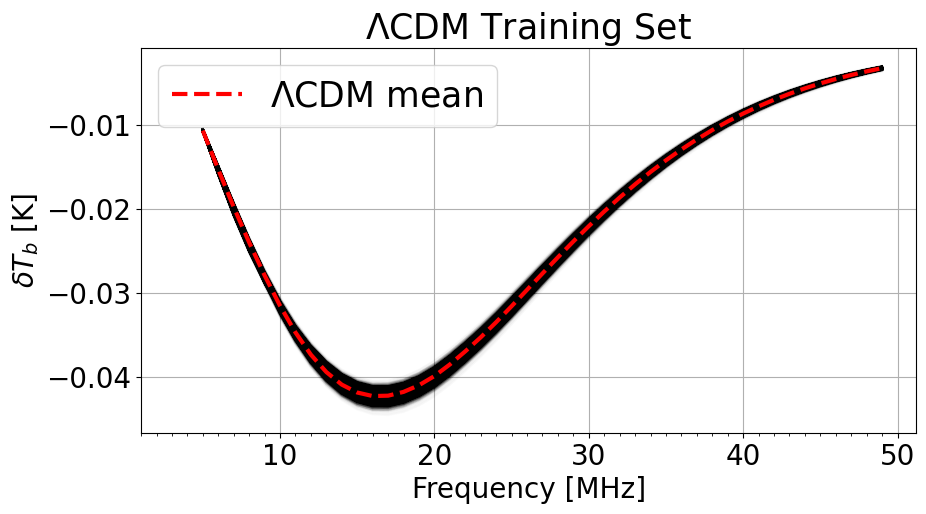

In [14]:
## Lambda CDM Training Set

### Construction ###

# parameter_array = np.array([[omR0,0],[omM0h2,0.013*h**2],[omK0,0],[omL0,0.0062],[omB0h2,0.00014],[H0,0]])
# frequencies=np.arange(1,50,0.5)
# signal_training_set_lambdaCDM=py21cmsig.lambdaCDM_training_set(frequencies,parameter_array,10000)
# # #lambda CDM
# hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/labmda_CDM_training_set_10k_90bins","w")
# hdf5.create_dataset("curves", data=signal_training_set_lambdaCDM[0])
# hdf5.create_dataset("parameters", data=signal_training_set_lambdaCDM[1])
# hdf5.close()

### Figure ###

frequencies
plt.figure(figsize=(10, 5))

for n in np.arange(10000):
    plt.plot(frequencies,lambdaCDM_training_set[n,16::4], color=fiducial_color, alpha=0.01)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=3,color='red',label=r"$\Lambda$CDM mean")
plt.xticks(ticks=np.arange(1,51,1),minor=True)
plt.xticks(size=20)
plt.xlabel("Frequency [MHz]",fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel(r"$\delta T_b$ [K]",fontsize=20)
plt.title(r"$\Lambda$CDM Training Set", fontsize=25)
plt.legend(fontsize=25)
plt.grid()

## Primordial Black Holes Parameter Space

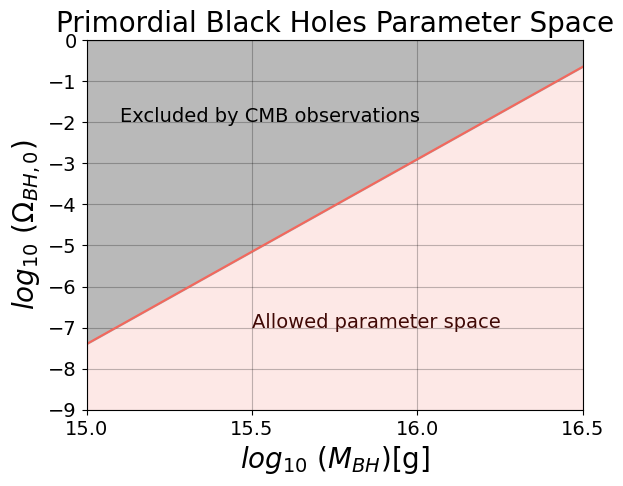

In [16]:
## Primordial Black Holes Parameter Space ##

### Construction and Figure ###

x = np.arange(15,16.6,0.01)
y = np.arange(-9,0)
line_function = lambda x,m,b: m*x+b
m=4.5
b=-74.9
parameter_line = line_function(x,m,b)
plt.xlim(15,16.5)
plt.ylim(-9,0)
plt.plot(x,parameter_line,color=PBH_color)
plt.fill_between(x,parameter_line,-20,alpha=0.15,color=PBH_color)
plt.fill_between(x,parameter_line,0,alpha=0.55,color="gray")
plt.text(15.1,-2,"Excluded by CMB observations",fontsize=14)
plt.text(15.5,-7,"Allowed parameter space",fontsize=14,color="#400906")
plt.title("Primordial Black Holes Parameter Space",fontsize=20)
plt.xlabel(r"$log_{10}$ ($M_{BH}$)[g]",fontsize=20)
plt.xticks([15,15.5,16,16.5])
plt.ylabel(r"$log_{10}$ ($\Omega_{BH,0}$)",fontsize=20)
plt.xticks(size=14)
plt.yticks(size=14)
plt.grid(color="black",alpha=0.25)

## All Signal Training Sets

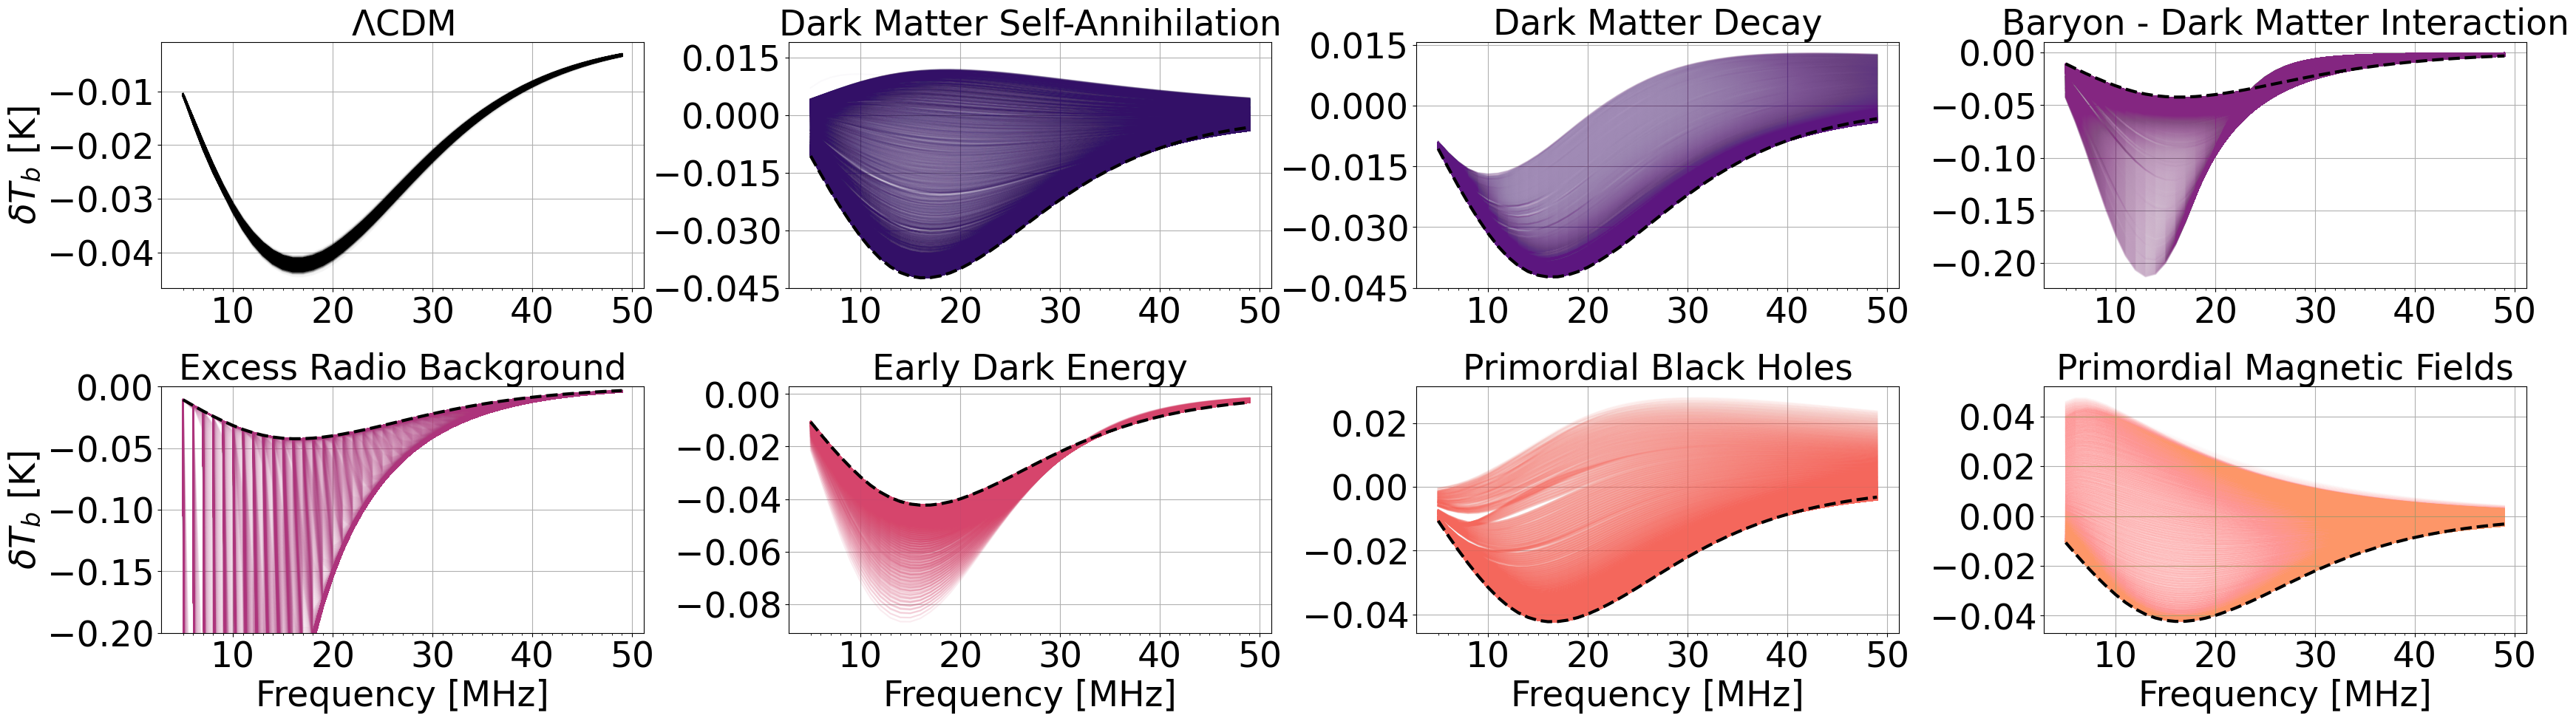

In [18]:
# Collumnation of all of the plots above (Horizontal)
title_font = 34
tick_font = 34
alpha = 0.01
fiducial_linewidth = 3
fig, axs = plt.subplots(2, 4, figsize=(40, 10)) #

#PMF
plt.subplot(2,4,8)
for n in np.arange(10000):
    plt.plot(frequencies,PMF_training_set_curves[n], color=PMF_color, alpha=0.005)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=fiducial_linewidth,color=fiducial_color,label=r"$\Lambda$CDM expectation")
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=tick_font)
plt.xlabel("Frequency [MHz]",fontsize=tick_font)
plt.yticks(fontsize=tick_font)
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(r"Primordial Magnetic Fields", fontsize=title_font)
plt.grid()

#PBH
plt.subplot(2,4,7)
for n in np.arange(10000):
    plt.plot(frequencies,PBH_training_set_curves[n], color=PBH_color, alpha=0.05)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=fiducial_linewidth,color=fiducial_color,label=r"$\Lambda$CDM expectation")
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=tick_font)
plt.xlabel("Frequency [MHz]",fontsize=tick_font)
plt.yticks(fontsize=tick_font)
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(r"Primordial Black Holes", fontsize=title_font)
plt.grid()

# EDE
plt.subplot(2,4,6)
for n in np.arange(10000):
    plt.plot(frequencies,EDE_training_set_curves[n], color=EDE_color, alpha=0.1)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=fiducial_linewidth,color=fiducial_color,label=r"$\Lambda$CDM expectation")
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=tick_font)
plt.xlabel("Frequency [MHz]",fontsize=tick_font)
plt.yticks(fontsize=tick_font)
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(r"Early Dark Energy", fontsize=title_font)
plt.grid()

# ERB
plt.subplot(2,4,5)
for n in np.arange(10000):
    plt.plot(frequencies,ERB_training_set_curves[n], color=ERB_color, alpha=0.05)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=fiducial_linewidth,color=fiducial_color,label=r"$\Lambda$CDM expectation")
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=tick_font)
plt.xlabel("Frequency [MHz]",fontsize=tick_font)
plt.yticks(fontsize=tick_font)
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
plt.ylabel(r"$\delta T_b$ [K]",fontsize=tick_font)
plt.title(r"Excess Radio Background", fontsize=title_font)
plt.ylim(-0.2,0)
plt.grid()

# MCDM
plt.subplot(2,4,4)
for n in np.arange(10000):
    plt.plot(frequencies,MCDM_training_set_curves[n], color=MCDM_color, alpha=0.01)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=fiducial_linewidth,color=fiducial_color,label=r"$\Lambda$CDM expectation")
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=tick_font)
# plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=tick_font)
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(r"Baryon - Dark Matter Interaction", fontsize=title_font)
plt.grid()

# DMD
plt.subplot(2,4,3)
for n in np.arange(10000):
    plt.plot(frequencies,DMD_training_set_curves[n], color=DMD_color, alpha=0.01)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=fiducial_linewidth,color=fiducial_color,label=r"$\Lambda$CDM expectation")
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=tick_font)
# plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=tick_font)
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(r"Dark Matter Decay", fontsize=title_font)
plt.grid()

# DMAN
plt.subplot(2,4,2)
for n in np.arange(10000):
    plt.plot(frequencies,DMAN_training_set_curves[n], color=DMAN_color, alpha=0.025)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=fiducial_linewidth,color=fiducial_color,label=r"$\Lambda$CDM expectation")
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=tick_font)
# plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=tick_font)
plt.ylim(-0.045,0.019)
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.ylabel(r"$\delta T_b$ [K]",fontsize=15)
plt.title(r"Dark Matter Self-Annihilation", fontsize=title_font)
plt.grid()

# CDM
plt.subplot(2,4,1)
for n in np.arange(10000):
    plt.plot(frequencies,lambdaCDM_training_set[n][16::4], color=fiducial_color, alpha=0.01)   #### Need to change 4 back to 16 if not using 50 frequency bins ####
plt.plot(frequencies,perses.models.LambdaCDMModel(frequencies,in_Kelvin=True)(fiducial_parameters),ls="--",linewidth=fiducial_linewidth,color=fiducial_color,label=r"$\Lambda$CDM expectation")
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=tick_font)
# plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=tick_font)
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.ylabel(r"$\delta T_b$ [K]",fontsize=tick_font)
plt.title(r"$\Lambda$CDM", fontsize=title_font)
# plt.legend(fontsize=20)
plt.grid() 

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.3, hspace=0.4)

### Construction of Training Sets

### Lambda CDM

In [ ]:
### Lambda CDM ###
# See Lambda CDM Training Set Section

### Dark Matter Self-Annihilation

In [ ]:
### DMAN ###

# model = perses.models.DarkMatterAnnihilationModel(frequencies,in_Kelvin=True)
# model_name = "DMAN"
# model_color = DMAN_color
# N_TS = 10000
# parameters = 2*np.logspace(-26, -22, N_TS)

# training_set_array = np.zeros((N_TS,len(frequencies)))
# for p in tqdm(np.arange(len(parameters))):
#     training_set_array[p] = model([parameters[p],1])

# hdf5 = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/{model_name}_training_set_uniform_sampling_45bins","w")
# hdf5.create_dataset("curves",data=training_set_array)
# hdf5.create_dataset("parameters",data=parameters)
# hdf5.close()

### Dark Matter Deacy

In [ ]:
## DMD ###

# model = perses.models.DarkMatterDecayModel(frequencies,in_Kelvin=True)
# model_name = "DMD"
# model_color = DMD_color
# N_TS = 10000
# parameters = 5*np.logspace(25, 28, N_TS)



# training_set_array = np.zeros((N_TS,len(frequencies)))
# for p in tqdm(np.arange(len(parameters))):
#     training_set_array[p] = model([parameters[p],1])

# hdf5 = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/{model_name}_training_set_uniform_sampling_45bins","w")
# hdf5.create_dataset("curves",data=training_set_array)
# hdf5.create_dataset("parameters",data=parameters)
# hdf5.close()

### Baryon-Dark Matter Interactions

In [ ]:
### MCDM ###

# model = perses.models.DarkMatterBaryonInteractionModel(frequencies,in_Kelvin=True)
# model_name = "MCDM"
# model_color = MCDM_color
# N_TS = 10000
# parameters = np.logspace(-2, 1, N_TS)



# training_set_array = np.zeros((N_TS,len(frequencies)))
# for p in tqdm(np.arange(len(parameters))):
#     training_set_array[p] = model([parameters[p],1])

# hdf5 = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/{model_name}_training_set_uniform_sampling_45bins","w")
# hdf5.create_dataset("curves",data=training_set_array)
# hdf5.create_dataset("parameters",data=parameters)
# hdf5.close()

### Early Dark Energy

In [ ]:
### EDE ###
# model = perses.models.EarlyDarkEnergyModel(frequencies,in_Kelvin=True)
# model_name = "EDE"
# model_color = EDE_color
# N_TS = 10000
# N_TS_per_parameter= int(np.sqrt(N_TS))
# parameter1 = 5*np.logspace(-10, -5, N_TS_per_parameter)
# parameter2 = np.logspace(1, 2, N_TS_per_parameter)

# ## Combine the paramters together
# combined_parameters = np.zeros((N_TS_per_parameter**2,2))
# index = 0
# for p1 in parameter1:
#     for p2 in parameter2:
#         index +=1
#         combined_parameters[index-1] = np.array([p1,p2])

# training_set_array = np.zeros((N_TS,len(frequencies)))
# for p in tqdm(np.arange(len(combined_parameters))):
#     training_set_array[p] = model(combined_parameters[p])

# hdf5 = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/{model_name}_training_set_uniform_sampling_45bins","w")
# hdf5.create_dataset("curves",data=training_set_array)
# hdf5.create_dataset("parameters",data=combined_parameters)
# hdf5.close()

### Excess Radio Background

In [ ]:
### ERB ###
# model = perses.models.ExcessRadioBackgroundModel(frequencies,in_Kelvin=True)
# model_name = "ERB"
# model_color = ERB_color
# N_TS = 10000
# N_TS_per_parameter= int(np.sqrt(N_TS))
# parameter1 = np.logspace(1.3, 3.04, N_TS_per_parameter)
# parameter2 = np.logspace(0, 2.57, N_TS_per_parameter)

# ## Combine the paramters together
# combined_parameters = np.zeros((N_TS_per_parameter**2,2))
# index = 0
# for p1 in parameter1:
#     for p2 in parameter2:
#         index +=1
#         combined_parameters[index-1] = np.array([p1,p2])

# training_set_array = np.zeros((N_TS,len(frequencies)))
# for p in tqdm(np.arange(len(combined_parameters))):
#     training_set_array[p] = model(combined_parameters[p])

# hdf5 = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/{model_name}_training_set_uniform_sampling_45bins","w")
# hdf5.create_dataset("curves",data=training_set_array)
# hdf5.create_dataset("parameters",data=combined_parameters)
# hdf5.close()

### Primordial Black Holes

In [ ]:
### PBH ###

# model = perses.models.PrimordialBlackHolesModel(frequencies,in_Kelvin=True)
# model_name = "PBH"
# model_color = PBH_color

# # --------------------------------------------------
# # Parameter space
# # --------------------------------------------------

# x_min = 15.0
# x_max = 16.6

# y_min = -9.0
# y_max_global = 0.0

# m = 4.5
# b = -74.9

# # --------------------------------------------------
# # Sampling resolution
# # --------------------------------------------------

# Nx = 132                 # Number of x values
# Ny_max = 132             # Maximum number of y values

# x = np.linspace(x_min, x_max, Nx)

# X = []
# Y = []

# for xi in x:

#     # Upper boundary at this x
#     y_upper = min(m * xi + b, y_max_global)

#     # Skip if outside allowed region
#     if y_upper <= y_min:
#         continue

#     # Height of allowed region
#     height = y_upper - y_min

#     # Scale number of y samples to keep density constant
#     Ny = max(2, int(np.round(Ny_max * height / (y_max_global - y_min))))

#     yi = np.linspace(y_min, y_upper, Ny)

#     X.append(np.full(Ny, xi))
#     Y.append(yi)

# X = np.concatenate(X)
# Y = np.concatenate(Y)

# # --------------------------------------------------
# # Convert back to physical parameter values
# # --------------------------------------------------

# parameter1 = 10**X
# parameter2 = 10**Y

# print(f"Generated {len(parameter1)} samples.")

# training_set_array = np.zeros((len(parameter1),len(frequencies)))
# index = -1
# for p1,p2 in tqdm(zip(parameter1,parameter2)):
#     index +=1
#     training_set_array[index] = model([p1,p2])

# N_TS_per_parameter = Nx*Ny_max
# combined_parameters = np.zeros((N_TS_per_parameter,2))
# index = 0
# for p1,p2 in zip(parameter1,parameter2):
#     index +=1
#     combined_parameters[index-1] = np.array([p1,p2])

# hdf5 = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/{model_name}_training_set_uniform_sampling_45bins","w")
# hdf5.create_dataset("curves",data=training_set_array)
# hdf5.create_dataset("parameters",data=combined_parameters)
# hdf5.close()

### Primordial Magnetic Fields

In [ ]:
### PMF ###

# model = perses.models.PrimordialMagneticFieldsModel(frequencies,in_Kelvin=True)
# model_name = "PMF"
# model_color = PMF_color
# N_TS = 10000
# N_TS_per_parameter= int(np.sqrt(N_TS))
# parameter2 = np.linspace(0.01, 0.5, N_TS_per_parameter)
# parameter1 = np.linspace(-2.99, 4, N_TS_per_parameter)

# ## Combine the paramters together
# combined_parameters = np.zeros((N_TS_per_parameter**2,2))
# index = 0
# for p1 in parameter1:
#     for p2 in parameter2:
#         index +=1
#         combined_parameters[index-1] = np.array([p1,p2])

# training_set_array = np.zeros((N_TS,len(frequencies)))
# for p in tqdm(np.arange(len(combined_parameters))):
#     training_set_array[p] = model(combined_parameters[p])



# hdf5 = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/{model_name}_training_set_uniform_sampling_45bins","w")
# hdf5.create_dataset("curves",data=training_set_array)
# hdf5.create_dataset("parameters",data=combined_parameters)
# hdf5.close()

## Foreground Training Sets

### 20% Foreground (5% $\Delta \alpha$)

In [101]:
# Conservative Foreground 
# Important variables:

parameter_variation = [0,0.05,0]   # First number is percent variation in Amplitude best fit to ULSA, second is percent variation spectral index best fit to ULSA, third is percent variation in spectral curvature best fit to ULSA.
N_TS = 10000     # Number of curves in the foreground training set


#### Code backend ####

n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)
  # Number of curves in the training set

sky_maps = master_foreground_array
sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
# Pylinex Extraction Variables
manual_systematics_terms = 0
manual_signal_terms = 0
num_sig_vectors = 3   # maximum number of signal modes to use in the extractions
num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
## signal that is used as the input to the observation data: ##
parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])
##  ##
signal_training_set = lambdaCDM_training_set[:,16::2]   ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit


#Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
# NPIX = hp.nside2npix(NSIDE)
# spectral_maps = np.zeros((n_LSTs,NPIX))
# for l in range(n_LSTs):
#     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
#     spectral_maps[l] = spectral_map

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
# f.create_dataset("spectral maps",data=spectral_maps)
# f.close()

if NSIDE != 32:
    raise ValueError ("The saved spectral maps are only 32 bit right now.")
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
# # Step 2: Create the monochromatic beam
for l in np.arange(n_LSTs):
    BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
    BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
    BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

# creates the B values
N=1
monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

for l in range(n_LSTs):
    patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
    region_indices = patch.foreground_pixel_indices_by_region_dictionary
    for r in range(n_regions):
        monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
# monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
monochromatic_gaussian_parameters = np.array([low_std])
# if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
#     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

# # Step 3: Create the beam-weighted foreground training set:
# # Step 3a: Create the BTS_curves to input to the foreground function:

# simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
parameter_variation_true = [0,0,0]   
simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                     np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[l]]))[0]

# The systematics training set itself
monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    extraction = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                     np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[l]]))
    monochro_beam_TS_10LSTs[:,l,:] = extraction[0]
full_systematics_TS_05 = monochro_beam_TS_10LSTs






100%|██████████| 10000/10000 [00:00<00:00, 58805.61it/s]


### 1% Foreground (0.25% $ \Delta \alpha$)

In [102]:
# Optimistic Foreground 
# Important variables:

parameter_variation = [0,0.0025,0]   # First number is percent variation in Amplitude best fit to ULSA, second is percent variation spectral index best fit to ULSA, third is percent variation in spectral curvature best fit to ULSA.
N_TS = 10000     # Number of curves in the foreground training set


#### Code backend ####

n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)
  # Number of curves in the training set

sky_maps = master_foreground_array
sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
# Pylinex Extraction Variables
manual_systematics_terms = 0
manual_signal_terms = 0
num_sig_vectors = 3   # maximum number of signal modes to use in the extractions
num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
## signal that is used as the input to the observation data: ##
parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])
##  ##
signal_training_set = lambdaCDM_training_set[:,16::2]   ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit


#Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
# NPIX = hp.nside2npix(NSIDE)
# spectral_maps = np.zeros((n_LSTs,NPIX))
# for l in range(n_LSTs):
#     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
#     spectral_maps[l] = spectral_map

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
# f.create_dataset("spectral maps",data=spectral_maps)
# f.close()

if NSIDE != 32:
    raise ValueError ("The saved spectral maps are only 32 bit right now.")
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
# # Step 2: Create the monochromatic beam
for l in np.arange(n_LSTs):
    BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
    BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
    BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

# creates the B values
N=1
monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

for l in range(n_LSTs):
    patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
    region_indices = patch.foreground_pixel_indices_by_region_dictionary
    for r in range(n_regions):
        monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
# monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
monochromatic_gaussian_parameters = np.array([low_std])
# if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
#     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

# # Step 3: Create the beam-weighted foreground training set:
# # Step 3a: Create the BTS_curves to input to the foreground function:

# simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
parameter_variation_true = [0,0,0]   
simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                     np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[l]]))[0]

# The systematics training set itself
monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    extraction = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                     np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[l]]))
    monochro_beam_TS_10LSTs[:,l,:] = extraction[0]
full_systematics_TS_0025 = monochro_beam_TS_10LSTs






100%|██████████| 10000/10000 [00:00<00:00, 57055.27it/s]


### 0.1% (0.025% $\Delta \alpha$)

In [31]:
# Overlap-Minimized Foreground 
# Important variables:

parameter_variation = [0,0.00025,0]   # First number is percent variation in Amplitude best fit to ULSA, second is percent variation spectral index best fit to ULSA, third is percent variation in spectral curvature best fit to ULSA.
N_TS = 10000     # Number of curves in the foreground training set


#### Code backend ####

n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)
  # Number of curves in the training set

sky_maps = master_foreground_array
sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
# Pylinex Extraction Variables
manual_systematics_terms = 0
manual_signal_terms = 0
num_sig_vectors = 3   # maximum number of signal modes to use in the extractions
num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
## signal that is used as the input to the observation data: ##
parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])
##  ##
signal_training_set = lambdaCDM_training_set[:,16::2]   ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit


#Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
# NPIX = hp.nside2npix(NSIDE)
# spectral_maps = np.zeros((n_LSTs,NPIX))
# for l in range(n_LSTs):
#     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
#     spectral_maps[l] = spectral_map

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
# f.create_dataset("spectral maps",data=spectral_maps)
# f.close()

if NSIDE != 32:
    raise ValueError ("The saved spectral maps are only 32 bit right now.")
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
# # Step 2: Create the monochromatic beam
for l in np.arange(n_LSTs):
    BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
    BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
    BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

# creates the B values
N=1
monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

for l in range(n_LSTs):
    patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
    region_indices = patch.foreground_pixel_indices_by_region_dictionary
    for r in range(n_regions):
        monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
# monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
monochromatic_gaussian_parameters = np.array([low_std])
# if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
#     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

# # Step 3: Create the beam-weighted foreground training set:
# # Step 3a: Create the BTS_curves to input to the foreground function:

# simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
parameter_variation_true = [0,0,0]   
simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                     np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[l]]))[0]

# The systematics training set itself
monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    extraction = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                     np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                       np.array([BTS_curves_monochromaticbeam[l]]))
    monochro_beam_TS_10LSTs[:,l,:] = extraction[0]
full_systematics_TS_00025 = monochro_beam_TS_10LSTs






100%|██████████| 10000/10000 [00:00<00:00, 56095.11it/s]


In [99]:
r = 7
p = 1
print(extraction[2][:,r,p].min())
print(extraction[2][:,r,p].max())


-2.6990969801474147
-2.6977478395079846


### All Foregrounds Figure

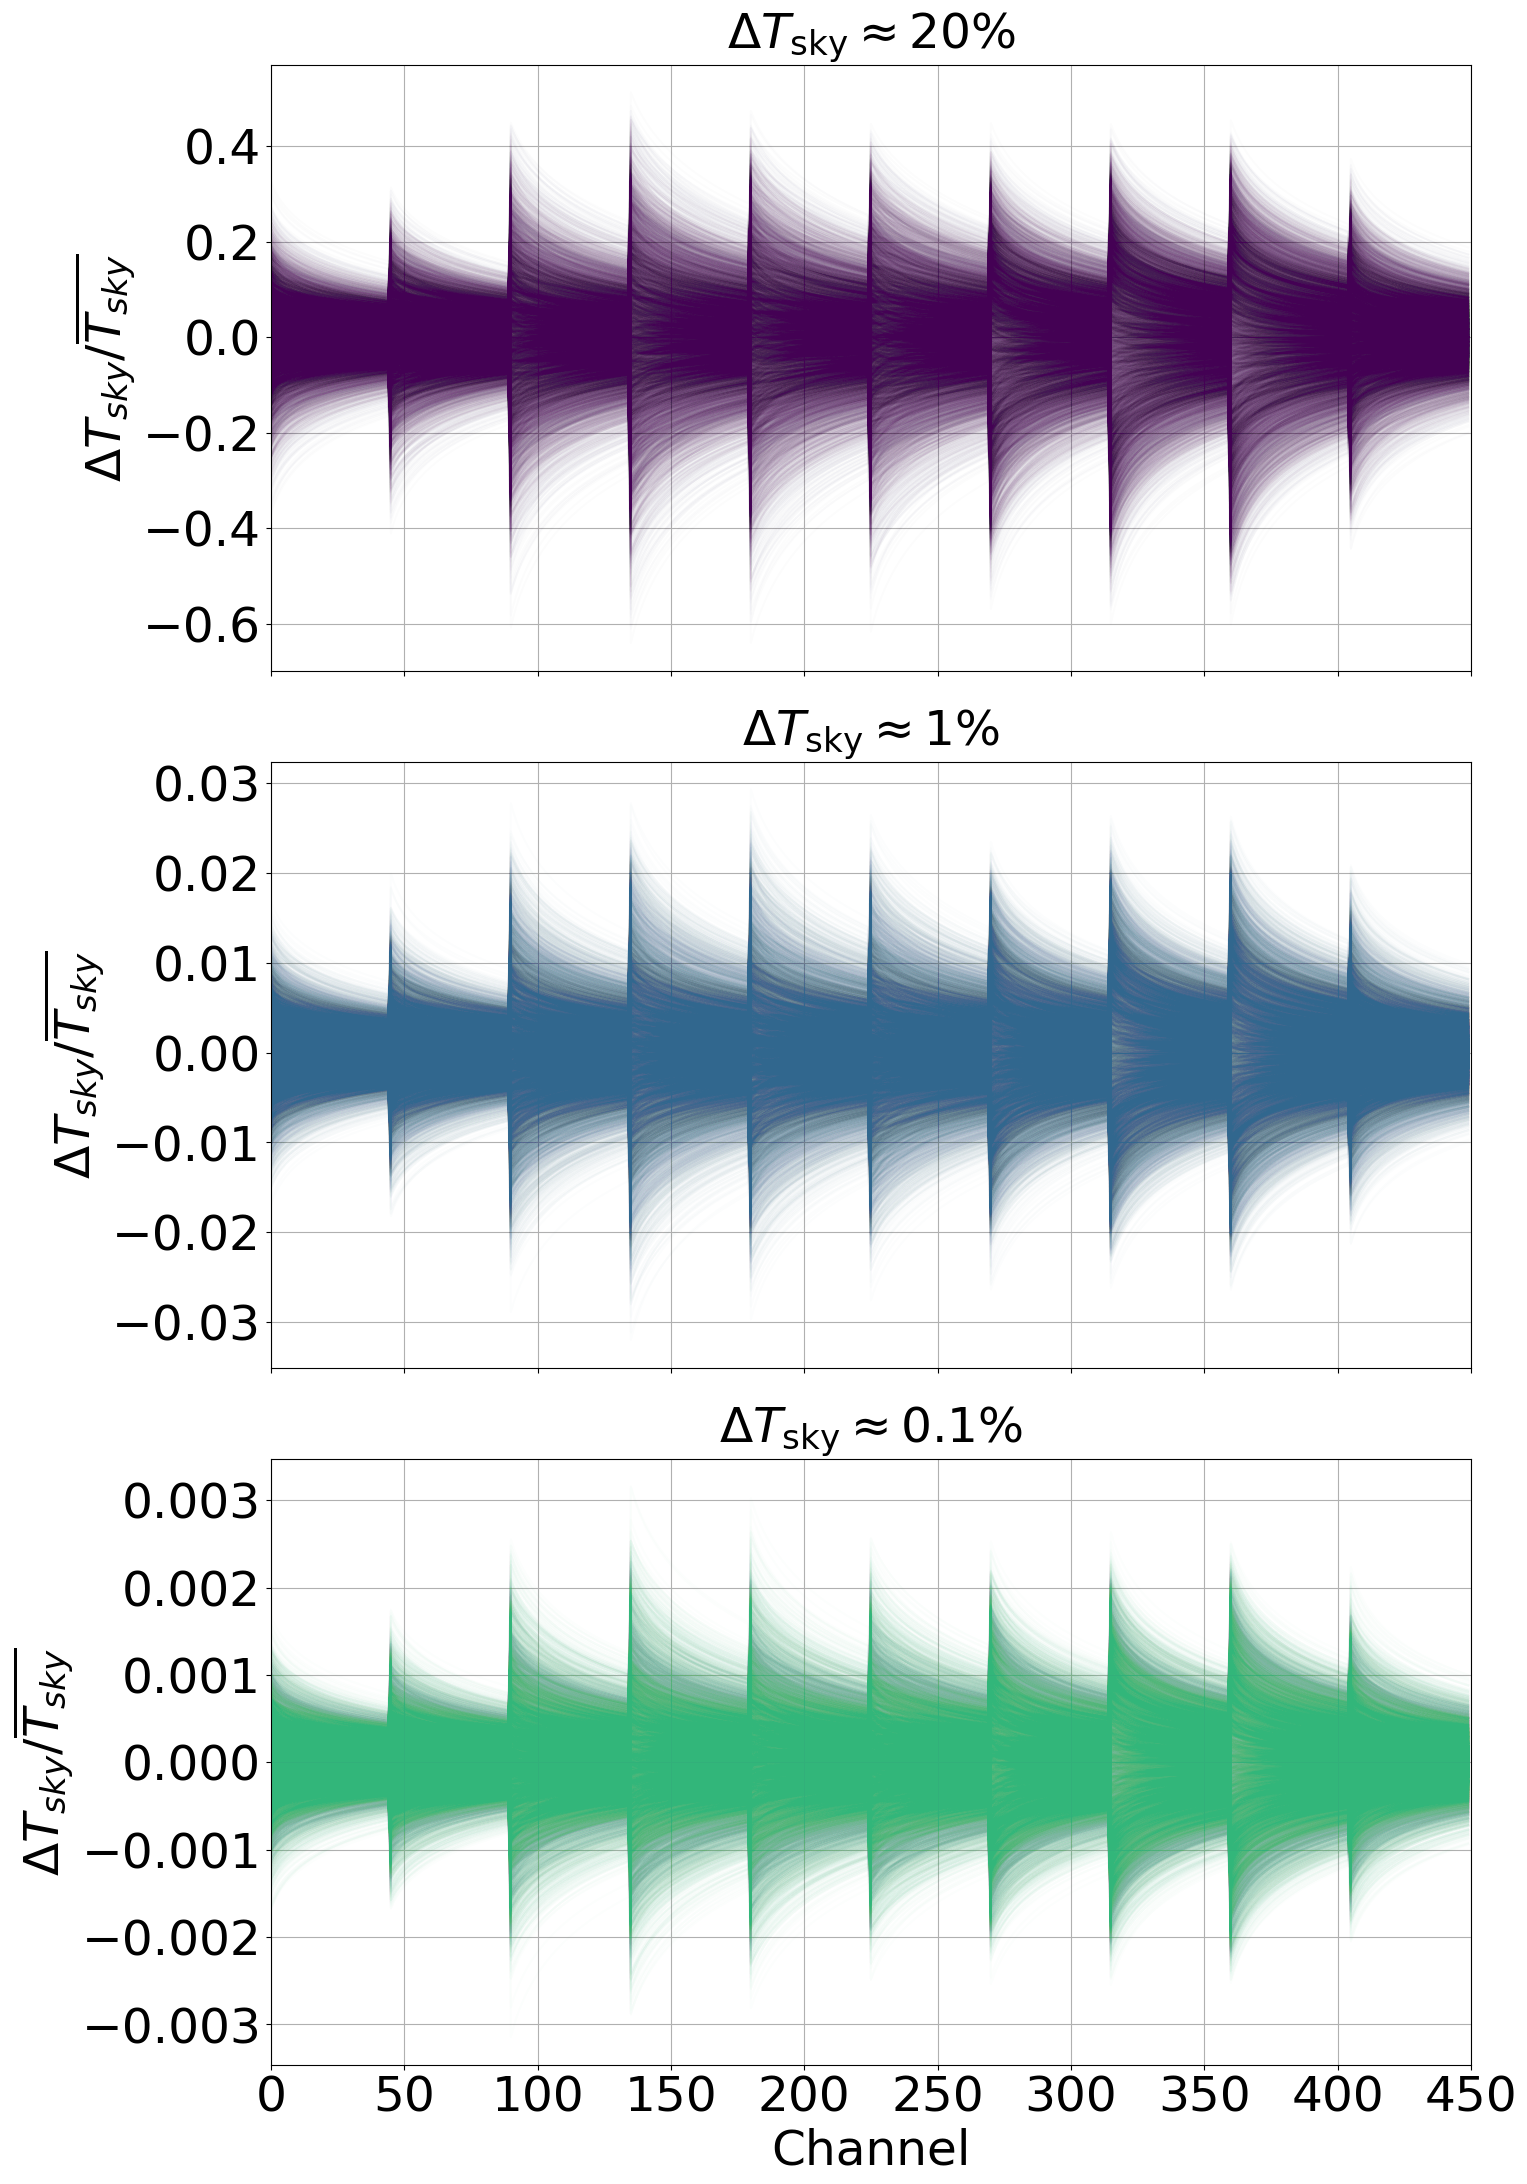

In [106]:
# All Foreground Figure

### Mean Translation ###

master_LST_array_05 = full_systematics_TS_05[:,0,:]/full_systematics_TS_05[:,0,:].mean(axis=0)
for l in range(1,10):
    master_LST_array_05=np.concatenate((master_LST_array_05,full_systematics_TS_05[:,l,:]/full_systematics_TS_05[:,l,:].mean(axis=0)),axis=1)
master_LST_array_0025 = full_systematics_TS_0025[:,0,:]/full_systematics_TS_0025[:,0,:].mean(axis=0)
for l in range(1,10):
    master_LST_array_0025=np.concatenate((master_LST_array_0025,full_systematics_TS_0025[:,l,:]/full_systematics_TS_0025[:,l,:].mean(axis=0)),axis=1)
master_LST_array_00025 = full_systematics_TS_00025[:,0,:]/full_systematics_TS_00025[:,0,:].mean(axis=0)
for l in range(1,10):
    master_LST_array_00025=np.concatenate((master_LST_array_00025,full_systematics_TS_00025[:,l,:]/full_systematics_TS_00025[:,l,:].mean(axis=0)),axis=1)

### Figure ###
# beam weighted foreground
fig, axs = plt.subplots(3, 1, figsize=(15 ,25),sharex=True) #
channels=np.arange(0,450)

plt.subplot(3,1,1)
for n in master_LST_array_05:
    plt.plot(channels,1-n,alpha=0.01,color=CFG_color)

        
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=35)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax.xaxis.set_minor_locator(MaxNLocator(nbins=10))
# plt.xlabel("Frequency [MHz]",fontsize=15)
plt.yticks(fontsize=35)
plt.ylabel(r"$\Delta T_{sky} / \overline{T_{sky}}$",fontsize=35)
plt.title(r"$\Delta T_{\rm sky} \approx 20\%$", fontsize=35)
plt.xlim(0,450)
# plt.ylim(0.45,1.65)
plt.grid()
# plt.legend()

plt.subplot(3,1,2)
for n in master_LST_array_0025:
    plt.plot(channels,1-n,alpha=0.01,color=OFG_color)

        
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=35)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax.xaxis.set_minor_locator(MaxNLocator(nbins=10))
# plt.xlabel("Channel",fontsize=35)
plt.yticks(fontsize=35)
plt.ylabel(r"$\Delta T_{sky} / \overline{T_{sky}}$",fontsize=35)
plt.title(r"$\Delta T_{\rm sky} \approx 1\%$", fontsize=35)
plt.xlim(0,450)
# plt.ylim(0.994,1.006)
plt.grid()
# plt.legend()

plt.subplot(3,1,3)
for n in master_LST_array_00025:
    plt.plot(channels,1-n,alpha=0.01,color=MFG_color)

        
plt.xticks(ticks=np.arange(5,51,1),minor=True)
plt.xticks(size=35)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax.xaxis.set_minor_locator(MaxNLocator(nbins=10))
# ax.yaxis.get_offset_text().set_fontsize(25)
plt.xlabel("Channel",fontsize=35)
plt.yticks(fontsize=35)
plt.ylabel(r"$\Delta T_{sky} / \overline{T_{sky}}$",fontsize=35)
plt.title(r"$\Delta T_{\rm sky} \approx 0.1\%$", fontsize=35)
plt.xlim(0,450)
# plt.ylim(0.994,1.006)
plt.grid()

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=1, hspace=0.15)

## $\Lambda$ CDM Detection

### Bayes Factor Comparison between foreground only and foreground plus $\Lambda$ CDM

Beginning processing of 10 antennas.


100%|██████████| 1000/1000 [11:40<00:00,  1.43it/s]


Beginning processing of 25 antennas.


100%|██████████| 1000/1000 [11:46<00:00,  1.42it/s]


Beginning processing of 100 antennas.


100%|██████████| 1000/1000 [11:46<00:00,  1.42it/s]


Beginning processing of 250 antennas.


100%|██████████| 1000/1000 [11:47<00:00,  1.41it/s]


Beginning processing of 1000 antennas.


100%|██████████| 1000/1000 [11:25<00:00,  1.46it/s]


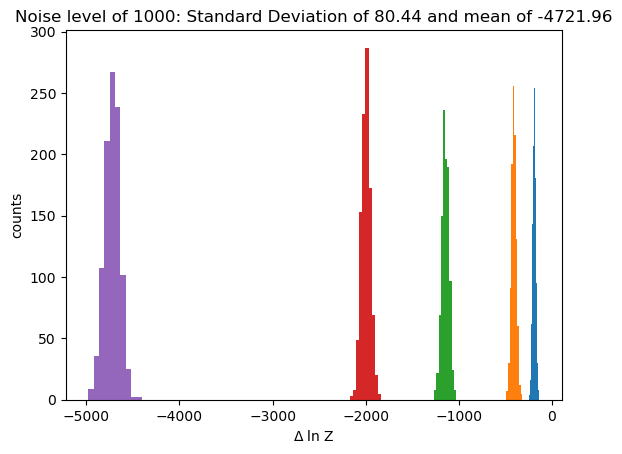

In [6]:
#### Optimistic Foreground ####



### User Variables ###
parameter_variation = [0,0.00000025,0]
constraint=str(parameter_variation[1])[2:]
N_antennas = np.array([10,25,100,250,1000])
dnu=1e6
dt=100*3600
N_extractions = 1000
N_TS = 10000   # Number of curves in the training set
input_signal = fiducial_signal
evidence_cutoff = 0

### Code Backend ###
plot=False
verbose = False
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)

quantity = AttributeQuantity("log_evidence")

for N_antenna in N_antennas:
    print(f"Beginning processing of {N_antenna} antennas.")
    sky_maps = master_foreground_array
    sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
    frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
    # Pylinex Extraction Variables
    manual_systematics_terms = 0
    manual_signal_terms = 0
    num_sig_vectors = 3 # maximum number of signal modes to use in the extractions
    num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
    num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
    ## signal that is used as the input to the observation data: ##
    parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])

    ##  ##
    signal_training_set = lambdaCDM_training_set[:,16::4]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit
    IC = "DIC"

    master_chi_squared_array = np.zeros(N_extractions)
    master_psi_squared_array = np.zeros(N_extractions)
    master_term_number_array = np.zeros(N_extractions)
    master_evidence_array = np.zeros(N_extractions)
    master_term_number_array_signal = np.zeros(N_extractions)

    # array for the Lambda CDM extraction (not the null signal, that's the ones above) 
    master_chi_squared_array_CDM = np.zeros(N_extractions)
    master_psi_squared_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM = np.zeros(N_extractions)
    master_evidence_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM_signal = np.zeros(N_extractions)


    #Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
    # NPIX = hp.nside2npix(NSIDE)
    # spectral_maps = np.zeros((n_LSTs,NPIX))
    # for l in range(n_LSTs):
    #     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
    #     spectral_maps[l] = spectral_map

    # f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
    # f.create_dataset("spectral maps",data=spectral_maps)
    # f.close()

    if NSIDE != 32:
        raise ValueError ("The saved spectral maps are only 32 bit right now.")
    hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
    spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

    BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
    # # Step 2: Create the monochromatic beam
    for l in np.arange(n_LSTs):
        BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
        BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
        BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

    # creates the B values
    N=1
    monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
    gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

    for l in range(n_LSTs):
        patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
        region_indices = patch.foreground_pixel_indices_by_region_dictionary
        for r in range(n_regions):
            monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
    # monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
    monochromatic_gaussian_parameters = np.array([low_std])
    # if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    #     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

    # # Step 3: Create the beam-weighted foreground training set:
    # # Step 3a: Create the BTS_curves to input to the foreground function:

    # simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
    parameter_variation_true = [0,0,0]   
    simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]

    # The systematics training set itself
    monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]



        #Pylinex Extractions



        extraction_dict = {}

        ### Pylinex part (doing it manually since we are only using the foreground for this) ###
    for index in tqdm(np.arange(N_extractions)):    

        static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,simulated_foreground_array_10LSTs,input_signal,N_antenna,dnu,dt)
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        systematics_training_set = monochro_beam_TS_10LSTs
        flattened_systematics_training_set = np.reshape(systematics_training_set, (len(systematics_training_set), -1))
        temperatures_flat = data.flatten()
        noise_level_flat = noise.flatten()
        Ns = len(noise)      # grabs the number of correlated spectra you are using
        names = ["systematics"]        # names of your bases
        bases = [
        TrainedBasis(
            training_set=flattened_systematics_training_set,
            num_basis_vectors=num_basis_vectors,
            error=noise_level_flat,
            expander=NullExpander(),
            mean_translation=True
        )]
        basis_sum = BasisSum(names,bases)
        dimension = [{'systematics' : np.arange(1,num_sys_vectors)}]
        priors = {"systematics_prior" : bases[0].gaussian_prior} 
        meta_fitter = MetaFitter(basis_sum, temperatures_flat, noise_level_flat, quantity, quantity.name, *dimension,**priors,verbose=False)      # creates the meta_fitter object, which is an essential Pylinex object
        logZ_grid = meta_fitter["log_evidence"]

        best_indices = np.unravel_index(
            np.argmax(logZ_grid),
            logZ_grid.shape
        )

        fitter = meta_fitter.fitter_from_indices(best_indices)

        # print("Best term numbers:", fitter.sizes)
        # print("Maximum log evidence:", fitter.log_evidence)
                                                                     
        num_systematics_terms = fitter.sizes["systematics"]                                                
        # plot for the signal extraction
        pylinex_error = fitter.subbasis_channel_error("systematics")
        radiometer_error = noise[0]
        # plt.plot((fitter.subbasis_channel_mean("systematics")-temperatures_flat)/noise_level_flat,label = "residual fit mean",color="blue")
        # print(f"systematic terms used: {num_systematics_terms}")
        # print(f"reduced chi squared: {fitter.reduced_chi_squared}")
        # print(f"reduced psi squared: {fitter.psi_squared}")
        chi_squared = fitter.reduced_chi_squared
        psi_squared = fitter.psi_squared
        term_number = num_systematics_terms

        master_chi_squared_array[index] = chi_squared
        master_psi_squared_array[index] = psi_squared
        master_term_number_array[index] = term_number   
        master_evidence_array[index] = fitter.log_evidence

            ##### Lambda CDM extractions
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        test_extraction_static_monochrome_LCDM = pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="log_evidence",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                        num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1\
                            ,evidence_cutoff=evidence_cutoff)



        master_chi_squared_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].reduced_chi_squared
        master_psi_squared_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].psi_squared
        master_term_number_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].sizes["systematics"]
        master_term_number_array_CDM_signal[index]  = test_extraction_static_monochrome_LCDM[0].sizes["signal"]
        master_evidence_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].log_evidence


    plt.hist(master_evidence_array-master_evidence_array_CDM)
    plt.xlabel(r"$\Delta$ ln Z")
    plt.ylabel("counts")
    plt.title(f"Noise level of {N_antenna}: Standard Deviation of {(master_evidence_array-master_evidence_array_CDM).std():.2f} and mean of {(master_evidence_array-master_evidence_array_CDM).mean():.2f}")
    f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian","w")
    f.attrs["Noise Value"] = N_antenna
    f.create_dataset("chi squared",data=master_chi_squared_array)
    f.create_dataset("psi squared",data=master_psi_squared_array)
    f.create_dataset("term number",data=master_term_number_array)
    f.create_dataset("Bayesian evidence",data=master_evidence_array)
    f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    f.create_dataset("foreground term number CDM",data=master_term_number_array_CDM)
    f.create_dataset("signal term number CDM",data=master_term_number_array_CDM_signal)
    f.create_dataset("Bayesian evidence CDM",data=master_evidence_array_CDM)
    f.close()


0.05

Beginning processing of 05 constraint.


100%|██████████| 10000/10000 [2:08:29<00:00,  1.30it/s] 


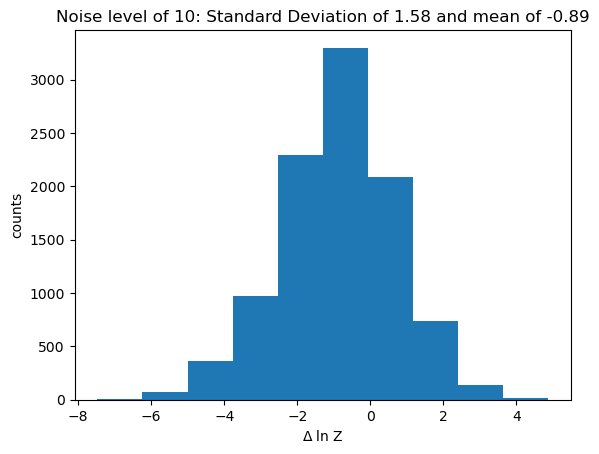

In [ ]:
#### Optimistic Foreground ####



### User Variables ###

# constraints = np.array([0.05,0.0025,0.00000025])
constraints = np.array([0.0025])
N_antenna = 10
dnu=1e6
dt=100*3600
N_extractions = 10000
N_TS = 10000   # Number of curves in the training set
input_signal = fiducial_signal
evidence_cutoff = 0

### Code Backend ###
plot=False
verbose = False
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)

quantity = AttributeQuantity("log_evidence")

for constraint_value in constraints:

    constraint=str(constraint_value)[2:]
    print(f"Beginning processing of {constraint} constraint.")
    parameter_variation = [0,constraint_value,0]
    sky_maps = master_foreground_array
    sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
    frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
    # Pylinex Extraction Variables
    manual_systematics_terms = 0
    manual_signal_terms = 0
    num_sig_vectors = 3 # maximum number of signal modes to use in the extractions
    num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
    num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
    ## signal that is used as the input to the observation data: ##
    parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])

    ##  ##
    signal_training_set = lambdaCDM_training_set[:,16::4]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit
    IC = "DIC"

    master_chi_squared_array = np.zeros(N_extractions)
    master_psi_squared_array = np.zeros(N_extractions)
    master_term_number_array = np.zeros(N_extractions)
    master_evidence_array = np.zeros(N_extractions)
    master_term_number_array_signal = np.zeros(N_extractions)

    # array for the Lambda CDM extraction (not the null signal, that's the ones above) 
    master_chi_squared_array_CDM = np.zeros(N_extractions)
    master_psi_squared_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM = np.zeros(N_extractions)
    master_evidence_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM_signal = np.zeros(N_extractions)


    #Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
    # NPIX = hp.nside2npix(NSIDE)
    # spectral_maps = np.zeros((n_LSTs,NPIX))
    # for l in range(n_LSTs):
    #     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
    #     spectral_maps[l] = spectral_map

    # f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
    # f.create_dataset("spectral maps",data=spectral_maps)
    # f.close()

    if NSIDE != 32:
        raise ValueError ("The saved spectral maps are only 32 bit right now.")
    hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
    spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

    BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
    # # Step 2: Create the monochromatic beam
    for l in np.arange(n_LSTs):
        BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
        BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
        BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

    # creates the B values
    N=1
    monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
    gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

    for l in range(n_LSTs):
        patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
        region_indices = patch.foreground_pixel_indices_by_region_dictionary
        for r in range(n_regions):
            monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
    # monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
    monochromatic_gaussian_parameters = np.array([low_std])
    # if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    #     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

    # # Step 3: Create the beam-weighted foreground training set:
    # # Step 3a: Create the BTS_curves to input to the foreground function:

    # simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
    parameter_variation_true = [0,0,0]   
    simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]

    # The systematics training set itself
    monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]



        #Pylinex Extractions



        extraction_dict = {}

        ### Pylinex part (doing it manually since we are only using the foreground for this) ###
    for index in tqdm(np.arange(N_extractions)):    

        static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,simulated_foreground_array_10LSTs,input_signal,N_antenna,dnu,dt)
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        systematics_training_set = monochro_beam_TS_10LSTs
        flattened_systematics_training_set = np.reshape(systematics_training_set, (len(systematics_training_set), -1))
        temperatures_flat = data.flatten()
        noise_level_flat = noise.flatten()
        Ns = len(noise)      # grabs the number of correlated spectra you are using
        names = ["systematics"]        # names of your bases
        bases = [
        TrainedBasis(
            training_set=flattened_systematics_training_set,
            num_basis_vectors=num_basis_vectors,
            error=noise_level_flat,
            expander=NullExpander(),
            mean_translation=True
        )]
        basis_sum = BasisSum(names,bases)
        dimension = [{'systematics' : np.arange(1,num_sys_vectors)}]
        priors = {"systematics_prior" : bases[0].gaussian_prior} 
        meta_fitter = MetaFitter(basis_sum, temperatures_flat, noise_level_flat, quantity, quantity.name, *dimension,**priors,verbose=False)      # creates the meta_fitter object, which is an essential Pylinex object
        logZ_grid = meta_fitter["log_evidence"]

        best_indices = np.unravel_index(
            np.argmax(logZ_grid),
            logZ_grid.shape
        )

        fitter = meta_fitter.fitter_from_indices(best_indices)

        # print("Best term numbers:", fitter.sizes)
        # print("Maximum log evidence:", fitter.log_evidence)
                                                                     
        num_systematics_terms = fitter.sizes["systematics"]                                                
        # plot for the signal extraction
        pylinex_error = fitter.subbasis_channel_error("systematics")
        radiometer_error = noise[0]
        # plt.plot((fitter.subbasis_channel_mean("systematics")-temperatures_flat)/noise_level_flat,label = "residual fit mean",color="blue")
        # print(f"systematic terms used: {num_systematics_terms}")
        # print(f"reduced chi squared: {fitter.reduced_chi_squared}")
        # print(f"reduced psi squared: {fitter.psi_squared}")
        chi_squared = fitter.reduced_chi_squared
        psi_squared = fitter.psi_squared
        term_number = num_systematics_terms

        master_chi_squared_array[index] = chi_squared
        master_psi_squared_array[index] = psi_squared
        master_term_number_array[index] = term_number   
        master_evidence_array[index] = fitter.log_evidence

            ##### Lambda CDM extractions
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        test_extraction_static_monochrome_LCDM = pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="log_evidence",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                        num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1\
                            ,evidence_cutoff=evidence_cutoff)



        master_chi_squared_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].reduced_chi_squared
        master_psi_squared_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].psi_squared
        master_term_number_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].sizes["systematics"]
        master_term_number_array_CDM_signal[index]  = test_extraction_static_monochrome_LCDM[0].sizes["signal"]
        master_evidence_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].log_evidence


    plt.hist(master_evidence_array-master_evidence_array_CDM)
    plt.xlabel(r"$\Delta$ ln Z")
    plt.ylabel("counts")
    plt.title(f"Noise level of {N_antenna}: Standard Deviation of {(master_evidence_array-master_evidence_array_CDM).std():.2f} and mean of {(master_evidence_array-master_evidence_array_CDM).mean():.2f}")
    f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k","w")
    f.attrs["Noise Value"] = N_antenna
    f.create_dataset("chi squared",data=master_chi_squared_array)
    f.create_dataset("psi squared",data=master_psi_squared_array)
    f.create_dataset("term number",data=master_term_number_array)
    f.create_dataset("Bayesian evidence",data=master_evidence_array)
    f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    f.create_dataset("foreground term number CDM",data=master_term_number_array_CDM)
    f.create_dataset("signal term number CDM",data=master_term_number_array_CDM_signal)
    f.create_dataset("Bayesian evidence CDM",data=master_evidence_array_CDM)
    f.close()


In [142]:
parameter_variation = [0,0.00000025,0]
constraint=str(parameter_variation[1])[2:]
constraint

'5e-07'

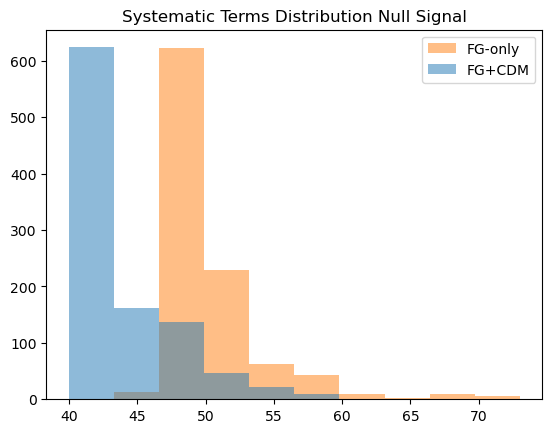

In [136]:
plt.hist([master_term_number_array_CDM,master_term_number_array],histtype="stepfilled",alpha=0.5,label=["FG+CDM","FG-only"])
plt.title("Systematic Terms Distribution Null Signal")
plt.legend()

Text(0.5, 1.0, 'Signal Term Distribution Null Signal')

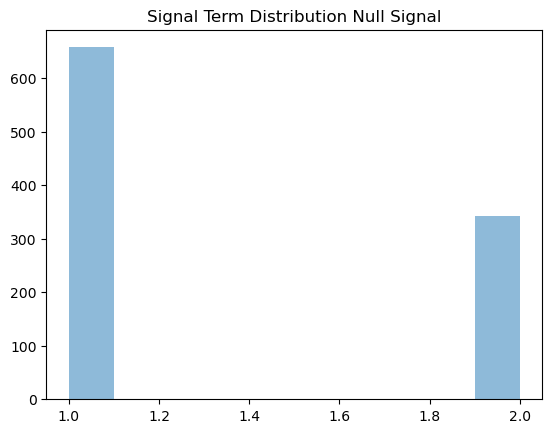

In [137]:
plt.hist([master_term_number_array_CDM_signal],histtype="stepfilled",alpha=0.5)
plt.title("Signal Term Distribution Null Signal")

In [ ]:
from collections import Counter

term_pairs = list(master_term_number_array_CDM
    zip(
        ,
        
    )
)

counts = Counter(term_pairs)

for pair, count in counts.most_common():
    print(pair, count)

(1, 1) 1
(2, 2) 1
(3, 3) 1


### Bayes Factor vs Term Number

In [ ]:
#### Optimistic Foreground ####



### User Variables ###
parameter_variation = [0,0.0025,0]
constraint="0025"
N_antenna = 10
dnu=1e6
dt=100*3600
N_extractions = 100
N_TS = 10000   # Number of curves in the training set



### Code Backend ###
plot=False
verbose = False
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)
# Pylinex Extraction Variables
num_sig_vectors = 3  # maximum number of signal modes to use in the extractions
num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
manual_systematics_terms = 0
manual_signal_terms = 0
quantity = AttributeQuantity("log_evidence")


sky_maps = master_foreground_array
sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies



## signal that is used as the input to the observation data: ##
parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])

##  ##
signal_training_set = lambdaCDM_training_set[:,16::4]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit
IC = "DIC"

master_chi_squared_array = np.zeros((N_extractions,num_sys_vectors))
master_psi_squared_array = np.zeros((N_extractions,num_sys_vectors))
master_term_number_array = np.zeros((N_extractions,num_sys_vectors))
master_evidence_array = np.zeros((N_extractions,num_sys_vectors))

# array for the Lambda CDM extraction (not the null signal, that's the ones above) 
master_chi_squared_array_CDM = np.zeros((N_extractions,num_sys_vectors))
master_psi_squared_array_CDM = np.zeros((N_extractions,num_sys_vectors))
master_term_number_array_CDM = np.zeros((N_extractions,num_sys_vectors))
master_evidence_array_CDM = np.zeros((N_extractions,num_sys_vectors))


#Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
# NPIX = hp.nside2npix(NSIDE)
# spectral_maps = np.zeros((n_LSTs,NPIX))
# for l in range(n_LSTs):
#     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
#     spectral_maps[l] = spectral_map

# f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
# f.create_dataset("spectral maps",data=spectral_maps)
# f.close()

if NSIDE != 32:
    raise ValueError ("The saved spectral maps are only 32 bit right now.")
hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
# # Step 2: Create the monochromatic beam
for l in np.arange(n_LSTs):
    BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
    BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
    BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

# creates the B values
N=1
monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

for l in range(n_LSTs):
    patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
    region_indices = patch.foreground_pixel_indices_by_region_dictionary
    for r in range(n_regions):
        monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
# monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
monochromatic_gaussian_parameters = np.array([low_std])
# if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
#     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

# # Step 3: Create the beam-weighted foreground training set:
# # Step 3a: Create the BTS_curves to input to the foreground function:

# simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
parameter_variation_true = [0,0,0]   
simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                    np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                    np.array([BTS_curves_monochromaticbeam[l]]))[0]

# The systematics training set itself
monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
for l in range(n_LSTs):
    monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                    np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                    np.array([BTS_curves_monochromaticbeam[l]]))[0]



    #Pylinex Extractions



extraction_dict = {}

    ### Pylinex part (doing it manually since we are only using the foreground for this) ###
for index in tqdm(np.arange(N_extractions)):
    for tn in np.arange(1,num_sys_vectors):
        print(f"Beginning processing of term {tn}.")    
        input_signal = np.zeros(len(frequencies))
        static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,simulated_foreground_array_10LSTs,input_signal,N_antenna,dnu,dt)
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        systematics_training_set = monochro_beam_TS_10LSTs
        flattened_systematics_training_set = np.reshape(systematics_training_set, (len(systematics_training_set), -1))
        temperatures_flat = data.flatten()
        noise_level_flat = noise.flatten()
        Ns = len(noise)      # grabs the number of correlated spectra you are using
        names = ["systematics"]        # names of your bases
        bases = [
        TrainedBasis(
            training_set=flattened_systematics_training_set,
            num_basis_vectors=num_basis_vectors,
            error=noise_level_flat,
            expander=NullExpander(),
            mean_translation=True
        )]
        basis_sum = BasisSum(names,bases)
        dimension = [{'systematics' : np.arange(tn,tn+1)}]
        priors = {"systematics_prior" : bases[0].gaussian_prior} 
        meta_fitter = MetaFitter(basis_sum, temperatures_flat, noise_level_flat, quantity, quantity.name, *dimension,**priors,verbose=False)      # creates the meta_fitter object, which is an essential Pylinex object
        logZ_grid = meta_fitter["log_evidence"]

        best_indices = np.unravel_index(
            np.argmax(logZ_grid),
            logZ_grid.shape
        )

        fitter = meta_fitter.fitter_from_indices(best_indices)

        print("Best term numbers:", fitter.sizes)
        print("Maximum log evidence:", fitter.log_evidence)
                                                                    
        num_systematics_terms = fitter.sizes["systematics"]                                                
        bases_for_least_squares = [TrainedBasis(training_set=flattened_systematics_training_set,num_basis_vectors=num_systematics_terms,error=noise_level_flat, expander=NullExpander())] 
        # plot for the signal extraction
        pylinex_error = fitter.subbasis_channel_error("systematics")
        radiometer_error = noise[0]
        # plt.plot((fitter.subbasis_channel_mean("systematics")-temperatures_flat)/noise_level_flat,label = "residual fit mean",color="blue")
        # print(f"systematic terms used: {num_systematics_terms}")
        # print(f"reduced chi squared: {fitter.reduced_chi_squared}")
        # print(f"reduced psi squared: {fitter.psi_squared}")
        chi_squared = fitter.reduced_chi_squared
        psi_squared = fitter.psi_squared
        term_number = num_systematics_terms

        master_chi_squared_array[index][tn] = chi_squared
        master_psi_squared_array[index][tn]  = psi_squared
        master_term_number_array[index][tn]  = term_number
        master_evidence_array[index][tn]  = fitter.log_evidence

            ##### Lambda CDM extractions
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        test_extraction_static_monochrome_LCDM = py21cmsig.pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="log_evidence",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                        num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=tn,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1)



        master_chi_squared_array_CDM[index][tn]  = test_extraction_static_monochrome_LCDM[0].reduced_chi_squared
        master_psi_squared_array_CDM[index][tn]   = test_extraction_static_monochrome_LCDM[0].psi_squared
        master_term_number_array_CDM[index][tn]   = test_extraction_static_monochrome_LCDM[0].sizes["systematics"]
        master_evidence_array_CDM[index][tn]  = test_extraction_static_monochrome_LCDM[0].log_evidence


    plt.hist(master_evidence_array-master_evidence_array_CDM)
    plt.xlabel(r"$\Delta$ ln Z")
    plt.ylabel("counts")
    plt.title(f"Noise level of {N_antenna}: Standard Deviation of {(master_evidence_array-master_evidence_array_CDM).std():.2f} and mean of {(master_evidence_array-master_evidence_array_CDM).mean():.2f}")
    # f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian","w")
    # f.attrs["Noise Value"] = N_antenna
    # f.create_dataset("chi squared",data=master_chi_squared_array)
    # f.create_dataset("psi squared",data=master_psi_squared_array)
    # f.create_dataset("term number",data=master_term_number_array)
    # f.create_dataset("Bayesian evidence",data=master_evidence_array)
    # f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    # f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    # f.create_dataset("term number CDM",data=master_term_number_array_CDM)
    # f.create_dataset("Bayesian evidence CDM",data=master_evidence_array_CDM)
    # f.close()


In [44]:
np.random.randint(N_TS)

9052

### Bayes Factor Analysis Using Foreground and CDM Variation

Beginning processing of 00025 constraint.


100%|██████████| 10000/10000 [1:57:48<00:00,  1.41it/s] 


Beginning processing of 5e-05 constraint.


100%|██████████| 10000/10000 [1:57:55<00:00,  1.41it/s] 


Beginning processing of 5e-06 constraint.


100%|██████████| 10000/10000 [1:55:59<00:00,  1.44it/s]


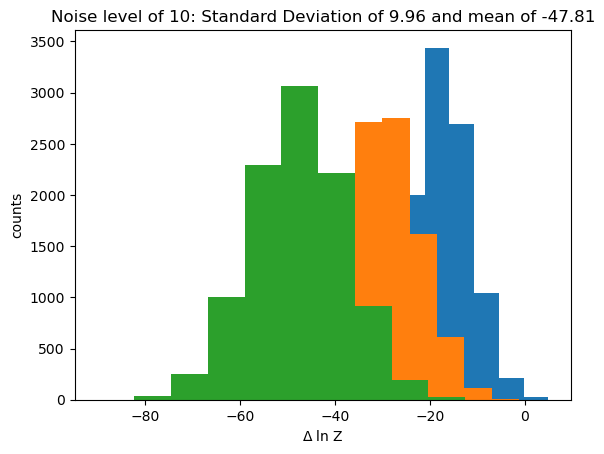

In [ ]:
#### Optimistic Foreground ####



### User Variables ###

constraints = np.array([0.05,0.0025,0.00025])
# constraints = np.array([0.00000025])
N_antenna = 10
dnu=1e6
dt=100*3600
N_extractions = 10000
N_TS = 10000   # Number of curves in the training set

evidence_cutoff = 0

### Code Backend ###
plot=False
verbose = False
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)

quantity = AttributeQuantity("log_evidence")

for constraint_value in constraints:

    constraint=str(constraint_value)[2:]
    print(f"Beginning processing of {constraint} constraint.")
    parameter_variation = [0,constraint_value,0]
    sky_maps = master_foreground_array
    sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
    frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
    # Pylinex Extraction Variables
    manual_systematics_terms = 0
    manual_signal_terms = 0
    num_sig_vectors = 3 # maximum number of signal modes to use in the extractions
    num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
    num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
    ## signal that is used as the input to the observation data: ##
    parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])

    ##  ##
    signal_training_set = lambdaCDM_training_set[:,16::4]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit
    IC = "DIC"

    master_chi_squared_array = np.zeros(N_extractions)
    master_psi_squared_array = np.zeros(N_extractions)
    master_term_number_array = np.zeros(N_extractions)
    master_evidence_array = np.zeros(N_extractions)
    master_term_number_array_signal = np.zeros(N_extractions)

    # array for the Lambda CDM extraction (not the null signal, that's the ones above) 
    master_chi_squared_array_CDM = np.zeros(N_extractions)
    master_psi_squared_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM = np.zeros(N_extractions)
    master_evidence_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM_signal = np.zeros(N_extractions)


    #Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
    # NPIX = hp.nside2npix(NSIDE)
    # spectral_maps = np.zeros((n_LSTs,NPIX))
    # for l in range(n_LSTs):
    #     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
    #     spectral_maps[l] = spectral_map

    # f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
    # f.create_dataset("spectral maps",data=spectral_maps)
    # f.close()

    if NSIDE != 32:
        raise ValueError ("The saved spectral maps are only 32 bit right now.")
    hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
    spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

    BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
    # # Step 2: Create the monochromatic beam
    for l in np.arange(n_LSTs):
        BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
        BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
        BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

    # creates the B values
    N=1
    monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
    gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

    for l in range(n_LSTs):
        patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
        region_indices = patch.foreground_pixel_indices_by_region_dictionary
        for r in range(n_regions):
            monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
    # monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
    monochromatic_gaussian_parameters = np.array([low_std])
    # if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    #     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

    # # Step 3: Create the beam-weighted foreground training set:
    # # Step 3a: Create the BTS_curves to input to the foreground function:

    # simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
    parameter_variation_true = [0,0,0]   
    simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]

    # The systematics training set itself
    monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]



        #Pylinex Extractions



        extraction_dict = {}

        ### Pylinex part (doing it manually since we are only using the foreground for this) ###
    for index in tqdm(np.arange(N_extractions)):  
        # input_signal = np.zeros(45)        
        input_signal = signal_training_set[np.random.randint(N_TS)]
        foreground = monochro_beam_TS_10LSTs[np.random.randint(N_TS)]
        static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,foreground,input_signal,N_antenna,dnu,dt)
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        systematics_training_set = monochro_beam_TS_10LSTs
        flattened_systematics_training_set = np.reshape(systematics_training_set, (len(systematics_training_set), -1))
        temperatures_flat = data.flatten()
        noise_level_flat = noise.flatten()
        Ns = len(noise)      # grabs the number of correlated spectra you are using
        names = ["systematics"]        # names of your bases
        bases = [
        TrainedBasis(
            training_set=flattened_systematics_training_set,
            num_basis_vectors=num_basis_vectors,
            error=noise_level_flat,
            expander=NullExpander(),
            mean_translation=True
        )]
        basis_sum = BasisSum(names,bases)
        dimension = [{'systematics' : np.arange(1,num_sys_vectors)}]
        priors = {"systematics_prior" : bases[0].gaussian_prior} 
        meta_fitter = MetaFitter(basis_sum, temperatures_flat, noise_level_flat, quantity, quantity.name, *dimension,**priors,verbose=False)      # creates the meta_fitter object, which is an essential Pylinex object
        logZ_grid = meta_fitter["log_evidence"]

        best_indices = np.unravel_index(
            np.argmax(logZ_grid),
            logZ_grid.shape
        )

        fitter = meta_fitter.fitter_from_indices(best_indices)

        # print("Best term numbers:", fitter.sizes)
        # print("Maximum log evidence:", fitter.log_evidence)
                                                                     
        num_systematics_terms = fitter.sizes["systematics"]                                                
        # plot for the signal extraction
        pylinex_error = fitter.subbasis_channel_error("systematics")
        radiometer_error = noise[0]
        # plt.plot((fitter.subbasis_channel_mean("systematics")-temperatures_flat)/noise_level_flat,label = "residual fit mean",color="blue")
        # print(f"systematic terms used: {num_systematics_terms}")
        # print(f"reduced chi squared: {fitter.reduced_chi_squared}")
        # print(f"reduced psi squared: {fitter.psi_squared}")
        chi_squared = fitter.reduced_chi_squared
        psi_squared = fitter.psi_squared
        term_number = num_systematics_terms

        master_chi_squared_array[index] = chi_squared
        master_psi_squared_array[index] = psi_squared
        master_term_number_array[index] = term_number   
        master_evidence_array[index] = fitter.log_evidence

            ##### Lambda CDM extractions
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        test_extraction_static_monochrome_LCDM = pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="log_evidence",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                        num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1\
                            ,evidence_cutoff=evidence_cutoff)



        master_chi_squared_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].reduced_chi_squared
        master_psi_squared_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].psi_squared
        master_term_number_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].sizes["systematics"]
        master_term_number_array_CDM_signal[index]  = test_extraction_static_monochrome_LCDM[0].sizes["signal"]
        master_evidence_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].log_evidence


    plt.hist(master_evidence_array-master_evidence_array_CDM)
    plt.xlabel(r"$\Delta$ ln Z")
    plt.ylabel("counts")
    plt.title(f"Noise level of {N_antenna}: Standard Deviation of {(master_evidence_array-master_evidence_array_CDM).std():.2f} and mean of {(master_evidence_array-master_evidence_array_CDM).mean():.2f}")
    f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation","w")
    f.attrs["Noise Value"] = N_antenna
    f.create_dataset("chi squared",data=master_chi_squared_array)
    f.create_dataset("psi squared",data=master_psi_squared_array)
    f.create_dataset("term number",data=master_term_number_array)
    f.create_dataset("Bayesian evidence",data=master_evidence_array)
    f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    f.create_dataset("foreground term number CDM",data=master_term_number_array_CDM)
    f.create_dataset("signal term number CDM",data=master_term_number_array_CDM_signal)
    f.create_dataset("Bayesian evidence CDM",data=master_evidence_array_CDM)
    f.close()


Beginning processing of 250 antennas.


100%|██████████| 10000/10000 [2:03:15<00:00,  1.35it/s] 


Beginning processing of 1000 antennas.


100%|██████████| 10000/10000 [2:02:23<00:00,  1.36it/s] 


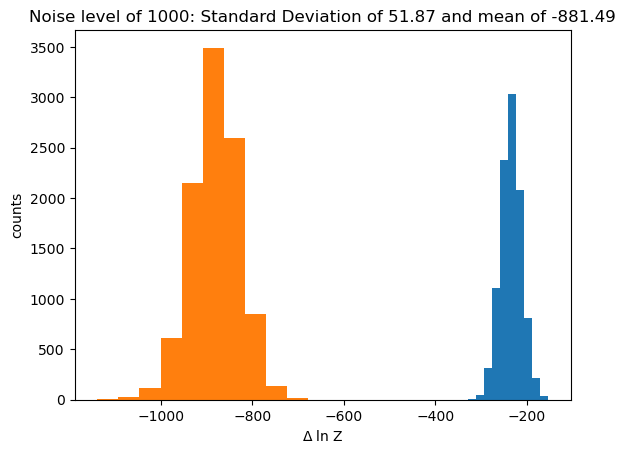

In [14]:
#### Optimistic Foreground ####



### User Variables ###

constraint_value = 0.00025
# constraints = np.array([0.00000025])
N_antennas = np.array([250,1000])
dnu=1e6
dt=100*3600
N_extractions = 10000
N_TS = 10000   # Number of curves in the training set

evidence_cutoff = 0

### Code Backend ###
plot=False
verbose = False
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)

quantity = AttributeQuantity("log_evidence")

for N_antenna in N_antennas:

    constraint=str(constraint_value)[2:]
    print(f"Beginning processing of {N_antenna} antennas.")
    parameter_variation = [0,constraint_value,0]
    sky_maps = master_foreground_array
    sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
    frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
    # Pylinex Extraction Variables
    manual_systematics_terms = 0
    manual_signal_terms = 0
    num_sig_vectors = 3 # maximum number of signal modes to use in the extractions
    num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
    num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
    ## signal that is used as the input to the observation data: ##
    parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])

    ##  ##
    signal_training_set = lambdaCDM_training_set[:,16::4]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit
    IC = "DIC"

    master_chi_squared_array = np.zeros(N_extractions)
    master_psi_squared_array = np.zeros(N_extractions)
    master_term_number_array = np.zeros(N_extractions)
    master_evidence_array = np.zeros(N_extractions)
    master_term_number_array_signal = np.zeros(N_extractions)

    # array for the Lambda CDM extraction (not the null signal, that's the ones above) 
    master_chi_squared_array_CDM = np.zeros(N_extractions)
    master_psi_squared_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM = np.zeros(N_extractions)
    master_evidence_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM_signal = np.zeros(N_extractions)


    #Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
    # NPIX = hp.nside2npix(NSIDE)
    # spectral_maps = np.zeros((n_LSTs,NPIX))
    # for l in range(n_LSTs):
    #     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
    #     spectral_maps[l] = spectral_map

    # f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
    # f.create_dataset("spectral maps",data=spectral_maps)
    # f.close()

    if NSIDE != 32:
        raise ValueError ("The saved spectral maps are only 32 bit right now.")
    hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
    spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

    BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
    # # Step 2: Create the monochromatic beam
    for l in np.arange(n_LSTs):
        BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
        BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
        BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

    # creates the B values
    N=1
    monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
    gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

    for l in range(n_LSTs):
        patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
        region_indices = patch.foreground_pixel_indices_by_region_dictionary
        for r in range(n_regions):
            monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
    # monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
    monochromatic_gaussian_parameters = np.array([low_std])
    # if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    #     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

    # # Step 3: Create the beam-weighted foreground training set:
    # # Step 3a: Create the BTS_curves to input to the foreground function:

    # simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
    parameter_variation_true = [0,0,0]   
    simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]

    # The systematics training set itself
    monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]



        #Pylinex Extractions



        extraction_dict = {}

        ### Pylinex part (doing it manually since we are only using the foreground for this) ###
    for index in tqdm(np.arange(N_extractions)):  
        # input_signal = np.zeros(45)        
        input_signal = signal_training_set[np.random.randint(N_TS)]
        foreground = monochro_beam_TS_10LSTs[np.random.randint(N_TS)]
        static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,foreground,input_signal,N_antenna,dnu,dt)
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        systematics_training_set = monochro_beam_TS_10LSTs
        flattened_systematics_training_set = np.reshape(systematics_training_set, (len(systematics_training_set), -1))
        temperatures_flat = data.flatten()
        noise_level_flat = noise.flatten()
        Ns = len(noise)      # grabs the number of correlated spectra you are using
        names = ["systematics"]        # names of your bases
        bases = [
        TrainedBasis(
            training_set=flattened_systematics_training_set,
            num_basis_vectors=num_basis_vectors,
            error=noise_level_flat,
            expander=NullExpander(),
            mean_translation=True
        )]
        basis_sum = BasisSum(names,bases)
        dimension = [{'systematics' : np.arange(1,num_sys_vectors)}]
        priors = {"systematics_prior" : bases[0].gaussian_prior} 
        meta_fitter = MetaFitter(basis_sum, temperatures_flat, noise_level_flat, quantity, quantity.name, *dimension,**priors,verbose=False)      # creates the meta_fitter object, which is an essential Pylinex object
        logZ_grid = meta_fitter["log_evidence"]

        best_indices = np.unravel_index(
            np.argmax(logZ_grid),
            logZ_grid.shape
        )

        fitter = meta_fitter.fitter_from_indices(best_indices)

        # print("Best term numbers:", fitter.sizes)
        # print("Maximum log evidence:", fitter.log_evidence)
                                                                     
        num_systematics_terms = fitter.sizes["systematics"]                                                
        # plot for the signal extraction
        pylinex_error = fitter.subbasis_channel_error("systematics")
        radiometer_error = noise[0]
        # plt.plot((fitter.subbasis_channel_mean("systematics")-temperatures_flat)/noise_level_flat,label = "residual fit mean",color="blue")
        # print(f"systematic terms used: {num_systematics_terms}")
        # print(f"reduced chi squared: {fitter.reduced_chi_squared}")
        # print(f"reduced psi squared: {fitter.psi_squared}")
        chi_squared = fitter.reduced_chi_squared
        psi_squared = fitter.psi_squared
        term_number = num_systematics_terms

        master_chi_squared_array[index] = chi_squared
        master_psi_squared_array[index] = psi_squared
        master_term_number_array[index] = term_number   
        master_evidence_array[index] = fitter.log_evidence

            ##### Lambda CDM extractions
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        test_extraction_static_monochrome_LCDM = pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="log_evidence",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                        num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1\
                            ,evidence_cutoff=evidence_cutoff)



        master_chi_squared_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].reduced_chi_squared
        master_psi_squared_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].psi_squared
        master_term_number_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].sizes["systematics"]
        master_term_number_array_CDM_signal[index]  = test_extraction_static_monochrome_LCDM[0].sizes["signal"]
        master_evidence_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].log_evidence


    plt.hist(master_evidence_array-master_evidence_array_CDM)
    plt.xlabel(r"$\Delta$ ln Z")
    plt.ylabel("counts")
    plt.title(f"Noise level of {N_antenna}: Standard Deviation of {(master_evidence_array-master_evidence_array_CDM).std():.2f} and mean of {(master_evidence_array-master_evidence_array_CDM).mean():.2f}")
    f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation","w")
    f.attrs["Noise Value"] = N_antenna
    f.create_dataset("chi squared",data=master_chi_squared_array)
    f.create_dataset("psi squared",data=master_psi_squared_array)
    f.create_dataset("term number",data=master_term_number_array)
    f.create_dataset("Bayesian evidence",data=master_evidence_array)
    f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    f.create_dataset("foreground term number CDM",data=master_term_number_array_CDM)
    f.create_dataset("signal term number CDM",data=master_term_number_array_CDM_signal)
    f.create_dataset("Bayesian evidence CDM",data=master_evidence_array_CDM)
    f.close()


In [ ]:
# f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation","w")
# f.attrs["Noise Value"] = N_antenna
# f.create_dataset("chi squared",data=master_chi_squared_array)
# f.create_dataset("psi squared",data=master_psi_squared_array)
# f.create_dataset("term number",data=master_term_number_array)
# f.create_dataset("Bayesian evidence",data=master_evidence_array)
# f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
# f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
# f.create_dataset("foreground term number CDM",data=master_term_number_array_CDM)
# f.create_dataset("signal term number CDM",data=master_term_number_array_CDM_signal)
# f.create_dataset("Bayesian evidence CDM",data=master_evidence_array_CDM)
# f.close()

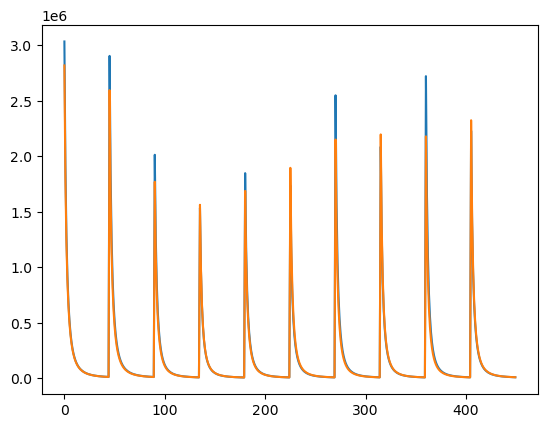

In [27]:
plt.plot(foreground.flatten())
plt.plot(simulated_foreground_array_10LSTs.flatten())

### Null test for Bayesian Evidence

Beginning processing of 10 antennas.


100%|██████████| 10000/10000 [1:56:50<00:00,  1.43it/s] 


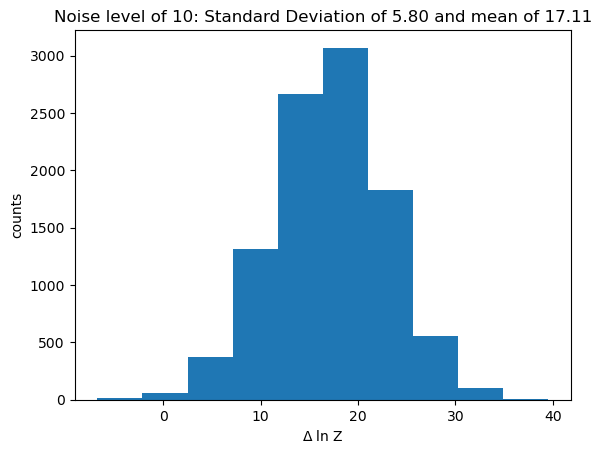

In [24]:
#### Optimistic Foreground ####



### User Variables ###

constraint_value = 0.00025
# constraints = np.array([0.00000025])
N_antennas = np.array([10])
dnu=1e6
dt=100*3600
N_extractions = 10000
N_TS = 10000   # Number of curves in the training set

evidence_cutoff = 0

### Code Backend ###
plot=False
verbose = False
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)

quantity = AttributeQuantity("log_evidence")

for N_antenna in N_antennas:

    constraint=str(constraint_value)[2:]
    print(f"Beginning processing of {N_antenna} antennas.")
    parameter_variation = [0,constraint_value,0]
    sky_maps = master_foreground_array
    sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
    frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
    # Pylinex Extraction Variables
    manual_systematics_terms = 0
    manual_signal_terms = 0
    num_sig_vectors = 3 # maximum number of signal modes to use in the extractions
    num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
    num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
    ## signal that is used as the input to the observation data: ##
    parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])

    ##  ##
    signal_training_set = lambdaCDM_training_set[:,16::4]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit
    IC = "DIC"

    master_chi_squared_array = np.zeros(N_extractions)
    master_psi_squared_array = np.zeros(N_extractions)
    master_term_number_array = np.zeros(N_extractions)
    master_evidence_array = np.zeros(N_extractions)
    master_term_number_array_signal = np.zeros(N_extractions)

    # array for the Lambda CDM extraction (not the null signal, that's the ones above) 
    master_chi_squared_array_CDM = np.zeros(N_extractions)
    master_psi_squared_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM = np.zeros(N_extractions)
    master_evidence_array_CDM = np.zeros(N_extractions)
    master_term_number_array_CDM_signal = np.zeros(N_extractions)


    #Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
    # NPIX = hp.nside2npix(NSIDE)
    # spectral_maps = np.zeros((n_LSTs,NPIX))
    # for l in range(n_LSTs):
    #     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
    #     spectral_maps[l] = spectral_map

    # f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
    # f.create_dataset("spectral maps",data=spectral_maps)
    # f.close()

    if NSIDE != 32:
        raise ValueError ("The saved spectral maps are only 32 bit right now.")
    hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
    spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

    BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
    # # Step 2: Create the monochromatic beam
    for l in np.arange(n_LSTs):
        BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
        BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
        BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

    # creates the B values
    N=1
    monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
    gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

    for l in range(n_LSTs):
        patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
        region_indices = patch.foreground_pixel_indices_by_region_dictionary
        for r in range(n_regions):
            monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
    # monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
    monochromatic_gaussian_parameters = np.array([low_std])
    # if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    #     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

    # # Step 3: Create the beam-weighted foreground training set:
    # # Step 3a: Create the BTS_curves to input to the foreground function:

    # simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
    parameter_variation_true = [0,0,0]   
    simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]

    # The systematics training set itself
    monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]



        #Pylinex Extractions



        extraction_dict = {}

        ### Pylinex part (doing it manually since we are only using the foreground for this) ###
    for index in tqdm(np.arange(N_extractions)):  
        input_signal = np.zeros(45)        
        # input_signal = signal_training_set[np.random.randint(N_TS)]
        foreground = monochro_beam_TS_10LSTs[np.random.randint(N_TS)]
        static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,foreground,input_signal,N_antenna,dnu,dt)
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        systematics_training_set = monochro_beam_TS_10LSTs
        flattened_systematics_training_set = np.reshape(systematics_training_set, (len(systematics_training_set), -1))
        temperatures_flat = data.flatten()
        noise_level_flat = noise.flatten()
        Ns = len(noise)      # grabs the number of correlated spectra you are using
        names = ["systematics"]        # names of your bases
        bases = [
        TrainedBasis(
            training_set=flattened_systematics_training_set,
            num_basis_vectors=num_basis_vectors,
            error=noise_level_flat,
            expander=NullExpander(),
            mean_translation=True
        )]
        basis_sum = BasisSum(names,bases)
        dimension = [{'systematics' : np.arange(1,num_sys_vectors)}]
        priors = {"systematics_prior" : bases[0].gaussian_prior} 
        meta_fitter = MetaFitter(basis_sum, temperatures_flat, noise_level_flat, quantity, quantity.name, *dimension,**priors,verbose=False)      # creates the meta_fitter object, which is an essential Pylinex object
        logZ_grid = meta_fitter["log_evidence"]

        best_indices = np.unravel_index(
            np.argmax(logZ_grid),
            logZ_grid.shape
        )

        fitter = meta_fitter.fitter_from_indices(best_indices)

        # print("Best term numbers:", fitter.sizes)
        # print("Maximum log evidence:", fitter.log_evidence)
                                                                     
        num_systematics_terms = fitter.sizes["systematics"]                                                
        # plot for the signal extraction
        pylinex_error = fitter.subbasis_channel_error("systematics")
        radiometer_error = noise[0]
        # plt.plot((fitter.subbasis_channel_mean("systematics")-temperatures_flat)/noise_level_flat,label = "residual fit mean",color="blue")
        # print(f"systematic terms used: {num_systematics_terms}")
        # print(f"reduced chi squared: {fitter.reduced_chi_squared}")
        # print(f"reduced psi squared: {fitter.psi_squared}")
        chi_squared = fitter.reduced_chi_squared
        psi_squared = fitter.psi_squared
        term_number = num_systematics_terms

        master_chi_squared_array[index] = chi_squared
        master_psi_squared_array[index] = psi_squared
        master_term_number_array[index] = term_number   
        master_evidence_array[index] = fitter.log_evidence

            ##### Lambda CDM extractions
        data=static_monchrome_beam_simulation[0]
        noise = static_monchrome_beam_simulation[5]
        signal = static_monchrome_beam_simulation[1]
        systematics = static_monchrome_beam_simulation[2]
        test_extraction_static_monochrome_LCDM = pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="log_evidence",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                        num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1\
                            ,evidence_cutoff=evidence_cutoff)



        master_chi_squared_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].reduced_chi_squared
        master_psi_squared_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].psi_squared
        master_term_number_array_CDM[index]  = test_extraction_static_monochrome_LCDM[0].sizes["systematics"]
        master_term_number_array_CDM_signal[index]  = test_extraction_static_monochrome_LCDM[0].sizes["signal"]
        master_evidence_array_CDM[index] = test_extraction_static_monochrome_LCDM[0].log_evidence


    plt.hist(master_evidence_array-master_evidence_array_CDM)
    plt.xlabel(r"$\Delta$ ln Z")
    plt.ylabel("counts")
    plt.title(f"Noise level of {N_antenna}: Standard Deviation of {(master_evidence_array-master_evidence_array_CDM).std():.2f} and mean of {(master_evidence_array-master_evidence_array_CDM).mean():.2f}")
    f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation_null","w")
    f.attrs["Noise Value"] = N_antenna
    f.create_dataset("chi squared",data=master_chi_squared_array)
    f.create_dataset("psi squared",data=master_psi_squared_array)
    f.create_dataset("term number",data=master_term_number_array)
    f.create_dataset("Bayesian evidence",data=master_evidence_array)
    f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    f.create_dataset("foreground term number CDM",data=master_term_number_array_CDM)
    f.create_dataset("signal term number CDM",data=master_term_number_array_CDM_signal)
    f.create_dataset("Bayesian evidence CDM",data=master_evidence_array_CDM)
    f.close()


17.114426350595597
5.798866133034832
0.02
0% of the 10,000 extractions will give a false positive for 20% foreground
0.06% of the 10,000 extractions will give a false positive for 1% foreground
0.02% of the 10,000 extractions will give a false positive for 0.1% foreground


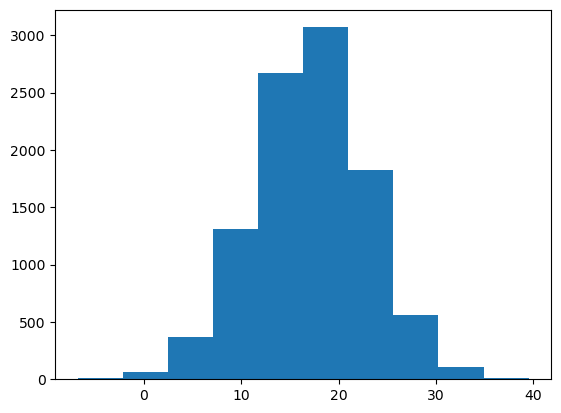

In [27]:
N_antenna = 10
constraint = "00025"   # Note: 0.00000025 = "5e-07"
f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation_null","r")
    # f.attrs["Noise Value"] = N_antenna
    # f.create_dataset("chi squared",data=master_chi_squared_array)
    # f.create_dataset("psi squared",data=master_psi_squared_array)
    # f.create_dataset("term number",data=master_term_number_array)
Bayesian_evidence = np.array(f["Bayesian evidence"])
    # f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    # f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    # f.create_dataset("term number CDM",data=master_term_number_array_CDM)
Bayesian_evidence_CDM = np.array(f["Bayesian evidence CDM"])
    # f.close()

log_diff_base = Bayesian_evidence-Bayesian_evidence_CDM
plt.hist(log_diff_base)
print(log_diff_base.mean())
print(log_diff_base.std())

### Percent Below -5 ###

print(np.where(log_diff_base<-5)[0].shape[0]/len(log_diff_base)*100)
print("0% of the 10,000 extractions will give a false positive for 20% foreground")
print("0.06% of the 10,000 extractions will give a false positive for 1% foreground")
print("0.02% of the 10,000 extractions will give a false positive for 0.1% foreground")

### Distinguishibility of Non Lambda CDM truth with CDM training set.

Beginning processing of 05 constraint.


100%|██████████| 10000/10000 [00:00<00:00, 54781.89it/s]


Beginning input curve number 0


100%|██████████| 100/100 [01:06<00:00,  1.51it/s]


Beginning input curve number 1


...

100%|██████████| 100/100 [01:08<00:00,  1.46it/s]


Beginning input curve number 98


100%|██████████| 100/100 [01:08<00:00,  1.45it/s]


Beginning input curve number 99


100%|██████████| 100/100 [01:08<00:00,  1.45it/s]


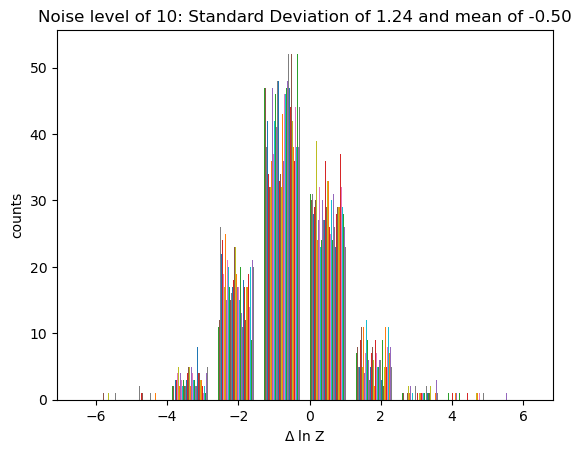

In [64]:
#### Optimistic Foreground ####



### User Variables ###

constraints = np.array([0.05])
# constraints = np.array([0.00000025])
N_antenna = 10
dnu=1e6
dt=100*3600
N_extractions = 100
N_TS = 10000   # Number of curves in the training set

evidence_cutoff = 0

### Code Backend ###
plot=False
verbose = False
n_LSTs = 10 # this should match the number of foreground_training_sets you've made
## Spectral Index Map Variable
n_regions = 8   # number of regions that are created for your multi-region model
temp1 = 20     # lower frequency that is used for the temperature for the spectral index of the spectral index map
temp2 = 50     # upper frequency
f_low = temp1   # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
f_high = temp2  # Only concerns the residual maps that are displayed through spectral_index_map_visualizations (not important for this)
NSIDE = 32
## Monochromatic Beam Variables.
N_beam = 1   # Number of beams to create. I'm not varying the beam right now, but this may be helpful later.
low_std = 0.5
high_std = low_std
## Synchrotron Foreground Variables
ylim = (-0.07,0.03)
input_signals = EDE_training_set_curves[::100]
parameter_values = EDE_training_set_parameters[::100]
quantity = AttributeQuantity("log_evidence")

for constraint_value in constraints:
  
    constraint=str(constraint_value)[2:]
    print(f"Beginning processing of {constraint} constraint.")
    parameter_variation = [0,constraint_value,0]
    sky_maps = master_foreground_array
    sky_maps_truncated = sky_maps[:,4:49,:]  # the trucated sky maps that map the frequency range of frequencies (though it may not match the number of bins)
    frequency_range_truncated = np.arange(5,50)  # Truncated frequency range that matches the sky map frequencies
    # Pylinex Extraction Variables
    manual_systematics_terms = 0
    manual_signal_terms = 0
    num_sig_vectors = 3 # maximum number of signal modes to use in the extractions
    num_sys_vectors = 75    # maximum number of systematic modes to use in the extraction
    num_basis_vectors = 75  # number of basis vectors to create for the root bases (make sure its as big as the largest num_sys or num_sig_vectors number)
    ## signal that is used as the input to the observation data: ##
    parameter_array = np.array([[omR0,0],[omM0h2,0],[omK0,0],[omL0,0],[omB0h2,0/h**2],[H0,0]])

    ##  ##
    signal_training_set = lambdaCDM_training_set[:,16::4]  ### indexing is needed to get it into the correct shape for the extraction. Training set used in the pylinex fit
    IC = "DIC"

    master_chi_squared_array = np.zeros((len(input_signals),N_extractions))
    master_psi_squared_array = np.zeros((len(input_signals),N_extractions))
    master_term_number_array = np.zeros((len(input_signals),N_extractions))
    master_evidence_array = np.zeros((len(input_signals),N_extractions))
    master_term_number_array_signal = np.zeros((len(input_signals),N_extractions))

    # array for the Lambda CDM extraction (not the null signal, that's the ones above) 
    master_chi_squared_array_CDM = np.zeros((len(input_signals),N_extractions))
    master_psi_squared_array_CDM = np.zeros((len(input_signals),N_extractions))
    master_term_number_array_CDM = np.zeros((len(input_signals),N_extractions))
    master_evidence_array_CDM = np.zeros((len(input_signals),N_extractions))
    master_term_number_array_CDM_signal = np.zeros((len(input_signals),N_extractions))


    #Step 1: Create the spectral index map that will govern the B_values of the beam (since they govern the indices of the regions).
    # NPIX = hp.nside2npix(NSIDE)
    # spectral_maps = np.zeros((n_LSTs,NPIX))
    # for l in range(n_LSTs):
    #     spectral_map = py21cmsig.spectral_index_map(f_low,f_high,n_regions,temp1,temp2,NSIDE,ULSA_direction_32 = master_foreground_array[l])
    #     spectral_maps[l] = spectral_map

    # f = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","w")
    # f.create_dataset("spectral maps",data=spectral_maps)
    # f.close()

    if NSIDE != 32:
        raise ValueError ("The saved spectral maps are only 32 bit right now.")
    hdf5 = h5py.File("/home/dbarker7752/21_cm_group/Exotic_Models_Data/spectral_index_map_10to50MHz_32bit","r")
    spectral_maps = np.array(hdf5["spectral maps"])   # I'v visually varified that these make sense

    BTS_curves_monochromaticbeam = np.zeros((n_LSTs,len(frequencies)))
    # # Step 2: Create the monochromatic beam
    for l in np.arange(n_LSTs):
        BTS_curves_monochromaticbeam_raw = (py21cmsig.gaussian_beams(frequency_range_truncated,low_std,resolution=NSIDE,monochromatic_mode=True)[0]*sky_maps_truncated).sum(axis=2)
        BTS_interpolator = scipy.interpolate.CubicSpline(frequency_range_truncated,BTS_curves_monochromaticbeam_raw[l])
        BTS_curves_monochromaticbeam[l] = BTS_interpolator(frequencies)

    # creates the B values
    N=1
    monochromatic_gaussian_B_values = np.zeros((n_LSTs,N,len(frequencies),n_regions))
    gaussian_beam_element = py21cmsig.gaussian_beams(frequencies,0.5,NSIDE,monochromatic_mode=True)

    for l in range(n_LSTs):
        patch=perses.models.PatchyForegroundModel(frequencies,spectral_maps[l],n_regions) # define the regional patches
        region_indices = patch.foreground_pixel_indices_by_region_dictionary
        for r in range(n_regions):
            monochromatic_gaussian_B_values[l,0,:,r] = gaussian_beam_element[:,region_indices[r]].sum(axis=1)
    # monochromatic_gaussian_B_values = py21cmsig.create_monochromatic_gaussian_beam_training_set(frequencies,N_beam,[low_std,high_std],n_LSTs,n_regions,NSIDE,spectral_maps,plot_extremes = True)[0]
    monochromatic_gaussian_parameters = np.array([low_std])
    # if len(frequencies) != monochromatic_gaussian_B_values[0][0].shape[0]:
    #     raise ValueError ("Your loaded B_values do not have the same length as your frequencies. This will cause problems later")

    # # Step 3: Create the beam-weighted foreground training set:
    # # Step 3a: Create the BTS_curves to input to the foreground function:

    # simulated_foreground_array sets the "true sky" observations that will be compared to the training sets for the extraction. It's your data, basically. 
    parameter_variation_true = [0,0,0]   
    simulated_foreground_array_10LSTs = np.zeros((n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        simulated_foreground_array_10LSTs[l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(1,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation_true,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([low_std]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]

    # The systematics training set itself
    monochro_beam_TS_10LSTs = np.zeros((N_TS,n_LSTs,len(frequencies)))
    for l in range(n_LSTs):
        monochro_beam_TS_10LSTs[:,l,:] = py21cmsig.synchrotron_foreground_updated_given_Bvalues(N_TS,n_regions,frequencies,spectral_maps[l],sky_maps[l],parameter_variation,\
                                                                                        np.array([monochromatic_gaussian_B_values[l,0]]),np.array([monochromatic_gaussian_parameters[0]]),\
                                                                                        np.array([BTS_curves_monochromaticbeam[l]]))[0]



        #Pylinex Extractions



        extraction_dict = {}

        ### Pylinex part (doing it manually since we are only using the foreground for this) ###
    for signal_index,input_signal in enumerate(input_signals):
        print(f"Beginning input curve number {signal_index}")
        for index in tqdm(np.arange(N_extractions)):  
            # input_signal = np.zeros(45)   

            # input_signal = signal_training_set[np.random.randint(N_TS)]
            foreground = monochro_beam_TS_10LSTs[np.random.randint(N_TS)]
            static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,foreground,input_signal,N_antenna,dnu,dt)
            data=static_monchrome_beam_simulation[0]
            noise = static_monchrome_beam_simulation[5]
            signal = static_monchrome_beam_simulation[1]
            systematics = static_monchrome_beam_simulation[2]
            systematics_training_set = monochro_beam_TS_10LSTs
            flattened_systematics_training_set = np.reshape(systematics_training_set, (len(systematics_training_set), -1))
            temperatures_flat = data.flatten()
            noise_level_flat = noise.flatten()
            Ns = len(noise)      # grabs the number of correlated spectra you are using
            names = ["systematics"]        # names of your bases
            bases = [
            TrainedBasis(
                training_set=flattened_systematics_training_set,
                num_basis_vectors=num_basis_vectors,
                error=noise_level_flat,
                expander=NullExpander(),
                mean_translation=True
            )]
            basis_sum = BasisSum(names,bases)
            dimension = [{'systematics' : np.arange(1,num_sys_vectors)}]
            priors = {"systematics_prior" : bases[0].gaussian_prior} 
            meta_fitter = MetaFitter(basis_sum, temperatures_flat, noise_level_flat, quantity, quantity.name, *dimension,**priors,verbose=False)      # creates the meta_fitter object, which is an essential Pylinex object
            logZ_grid = meta_fitter["log_evidence"]

            best_indices = np.unravel_index(
                np.argmax(logZ_grid),
                logZ_grid.shape
            )

            fitter = meta_fitter.fitter_from_indices(best_indices)

            # print("Best term numbers:", fitter.sizes)
            # print("Maximum log evidence:", fitter.log_evidence)
                                                                        
            num_systematics_terms = fitter.sizes["systematics"]                                                
            # plot for the signal extraction
            pylinex_error = fitter.subbasis_channel_error("systematics")
            radiometer_error = noise[0]
            # plt.plot((fitter.subbasis_channel_mean("systematics")-temperatures_flat)/noise_level_flat,label = "residual fit mean",color="blue")
            # print(f"systematic terms used: {num_systematics_terms}")
            # print(f"reduced chi squared: {fitter.reduced_chi_squared}")
            # print(f"reduced psi squared: {fitter.psi_squared}")
            chi_squared = fitter.reduced_chi_squared
            psi_squared = fitter.psi_squared
            term_number = num_systematics_terms

            master_chi_squared_array[signal_index][index] = chi_squared
            master_psi_squared_array[signal_index][index] = psi_squared
            master_term_number_array[signal_index][index] = term_number   
            master_evidence_array[signal_index][index] = fitter.log_evidence

                ##### Lambda CDM extractions
            data=static_monchrome_beam_simulation[0]
            noise = static_monchrome_beam_simulation[5]
            signal = static_monchrome_beam_simulation[1]
            systematics = static_monchrome_beam_simulation[2]
            test_extraction_static_monochrome_LCDM = pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="log_evidence",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                            num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1\
                                ,evidence_cutoff=evidence_cutoff)



            master_chi_squared_array_CDM[signal_index][index] = test_extraction_static_monochrome_LCDM[0].reduced_chi_squared
            master_psi_squared_array_CDM[signal_index][index]  = test_extraction_static_monochrome_LCDM[0].psi_squared
            master_term_number_array_CDM[signal_index][index]  = test_extraction_static_monochrome_LCDM[0].sizes["systematics"]
            master_term_number_array_CDM_signal[signal_index][index]  = test_extraction_static_monochrome_LCDM[0].sizes["signal"]
            master_evidence_array_CDM[signal_index][index] = test_extraction_static_monochrome_LCDM[0].log_evidence


    plt.hist(master_evidence_array-master_evidence_array_CDM)
    plt.xlabel(r"$\Delta$ ln Z")
    plt.ylabel("counts")
    plt.title(f"Noise level of {N_antenna}: Standard Deviation of {(master_evidence_array-master_evidence_array_CDM).std():.2f} and mean of {(master_evidence_array-master_evidence_array_CDM).mean():.2f}")
    # f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation","w")
    # f.attrs["Noise Value"] = N_antenna
    # f.create_dataset("chi squared",data=master_chi_squared_array)
    # f.create_dataset("psi squared",data=master_psi_squared_array)
    # f.create_dataset("term number",data=master_term_number_array)
    # f.create_dataset("Bayesian evidence",data=master_evidence_array)
    # f.create_dataset("input curve, data=input_signals")
    # f.create_dataset("curve parameters, data=parameter_values")
    # f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    # f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    # f.create_dataset("foreground term number CDM",data=master_term_number_array_CDM)
    # f.create_dataset("signal term number CDM",data=master_term_number_array_CDM_signal)
    # f.create_dataset("Bayesian evidence CDM",data=master_evidence_array_CDM)
    # f.close()


In [63]:
n=99
plt.hist(master_evidence_array[n]-master_evidence_array_CDM[n])
plt.show()
plt.plot(frequencies,EDE_training_set_curves[n])

IndexError: index 99 is out of bounds for axis 0 with size 10

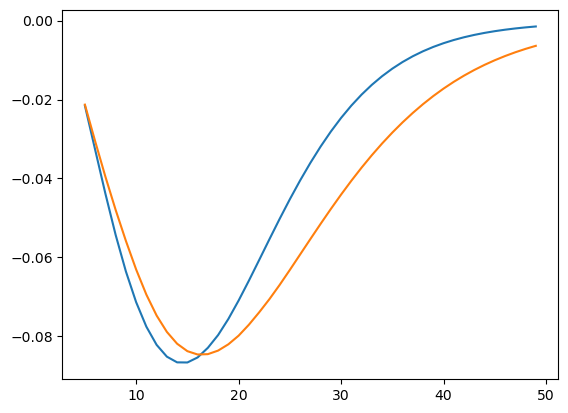

In [40]:
plt.plot(frequencies,EDE_training_set_curves[9999])
plt.plot(frequencies,fiducial_signal*2)

### Plot of Bayes Factor at Noise 10 For The 3 Foreground Sets

-21.528477924709044
6.5933843565071175


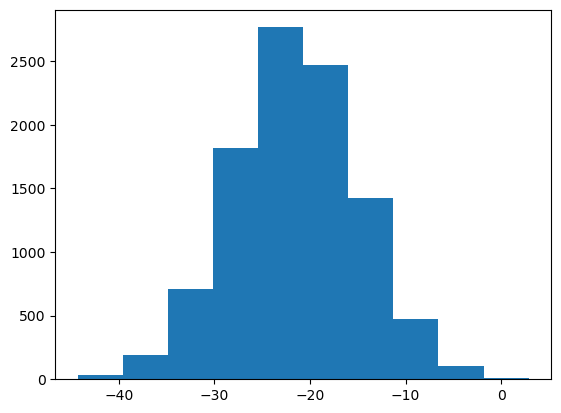

In [22]:
N_antenna = 25
constraint = "0025"   # Note: 0.00000025 = "5e-07"
f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation","r")
    # f.attrs["Noise Value"] = N_antenna
    # f.create_dataset("chi squared",data=master_chi_squared_array)
    # f.create_dataset("psi squared",data=master_psi_squared_array)
    # f.create_dataset("term number",data=master_term_number_array)
Bayesian_evidence = np.array(f["Bayesian evidence"])
    # f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    # f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    # f.create_dataset("term number CDM",data=master_term_number_array_CDM)
Bayesian_evidence_CDM = np.array(f["Bayesian evidence CDM"])
    # f.close()

log_diff_base = Bayesian_evidence-Bayesian_evidence_CDM
plt.hist(log_diff_base)
print(log_diff_base.mean())
print(log_diff_base.std())

<>:200: SyntaxWarning: invalid escape sequence '\%'
<>:200: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_29595/4046815961.py:200: SyntaxWarning: invalid escape sequence '\%'
  f"$= {100*detection_fraction:.1f}\%$"


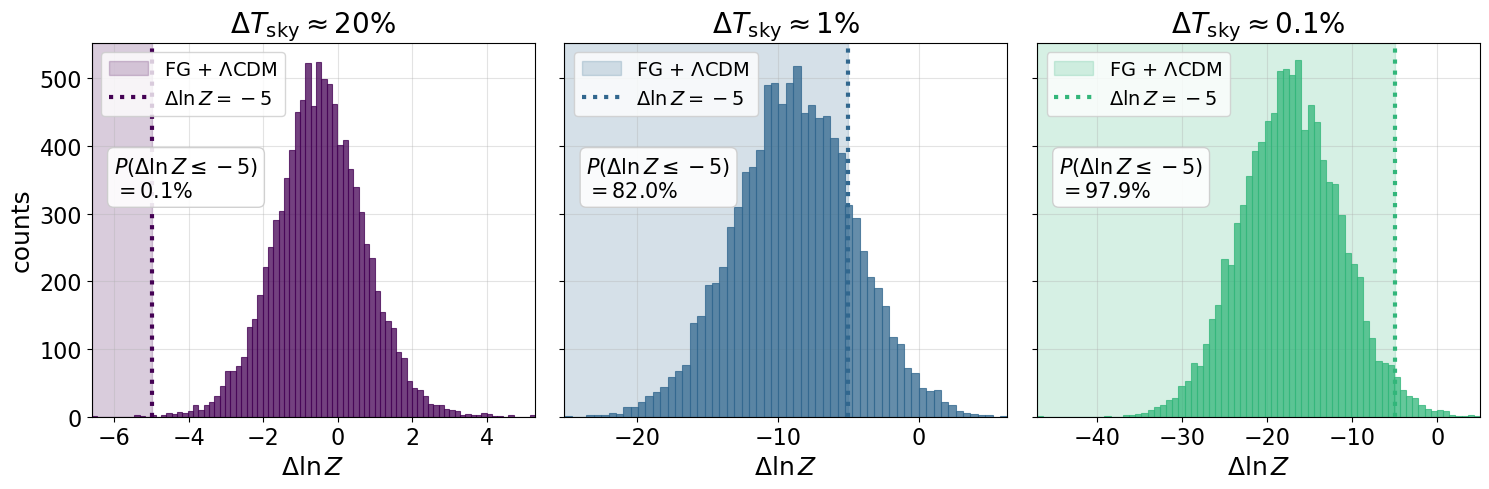

$\Delta T_{\rm sky} \approx 20\%$: mean = -0.482, std = 1.214, P(Delta ln Z <= -5) = 0.06%
$\Delta T_{\rm sky} \approx 1\%$: mean = -8.840, std = 4.228, P(Delta ln Z <= -5) = 81.96%
$\Delta T_{\rm sky} \approx 0.1\%$: mean = -17.221, std = 5.847, P(Delta ln Z <= -5) = 97.89%


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import h5py


# ======================================================
# USER INPUTS
# ======================================================

N_antenna = 10

constraint_suffixes = [
    "05",
    "0025",
    "00025"
]

titles = [
    r"$\Delta T_{\rm sky} \approx 20\%$",
    r"$\Delta T_{\rm sky} \approx 1\%$",
    r"$\Delta T_{\rm sky} \approx 0.1\%$"
]

colors = [
    CFG_color,
    OFG_color,
    MFG_color
]

# Robust Lambda-CDM detection threshold
detection_threshold = -5


# ======================================================
# LOAD LOG BAYES FACTOR DISTRIBUTIONS
# ======================================================

bayes_distributions = []

for constraint in constraint_suffixes:

    filename = (
        "/home/dbarker7752/21_cm_group/Exotic_Models_Data/"
        f"expected_distro_vs_Lambda_extract_"
        f"{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation"
    )

    with h5py.File(filename, "r") as f:

        foreground_logZ = np.array(
            f["Bayesian evidence"]
        )

        lambdaCDM_logZ = np.array(
            f["Bayesian evidence CDM"]
        )

    # --------------------------------------------------
    # Sign convention:
    #
    # Delta ln Z = ln Z_FG - ln Z_FG+LCDM
    #
    # Negative values favor FG + LambdaCDM.
    # Positive values favor foreground-only.
    #
    # Therefore:
    #
    # Delta ln Z <= -5
    #
    # represents robust evidence for LambdaCDM.
    # --------------------------------------------------

    delta_logZ = foreground_logZ - lambdaCDM_logZ

    bayes_distributions.append(delta_logZ)


# ======================================================
# FIGURE
# ======================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharey=True
)


for ax, delta_logZ, title, color in zip(
    axes,
    bayes_distributions,
    titles,
    colors
):

    delta_logZ = np.asarray(delta_logZ).flatten()


    # ==================================================
    # DETECTION FRACTION
    # ==================================================

    detection_fraction = np.mean(
        delta_logZ <= detection_threshold
    )


    # ==================================================
    # HISTOGRAM BINS
    # ==================================================

    bins = np.histogram_bin_edges(
        delta_logZ,
        bins="auto"
    )

    xmin = min(
        np.min(delta_logZ),
        detection_threshold
    )

    xmax = max(
        np.max(delta_logZ),
        0
    )


    # ==================================================
    # ROBUST-DETECTION REGION
    #
    # Everything left of Delta ln Z = -5 robustly
    # favors FG + LambdaCDM.
    # ==================================================

    ax.axvspan(
        xmin,
        detection_threshold,
        color=color,
        alpha=0.2,
        label=r"FG + $\Lambda$CDM",
        zorder=0
    )


    # ==================================================
    # LOG BAYES FACTOR DISTRIBUTION
    # ==================================================

    ax.hist(
        delta_logZ,
        bins=bins,
        color=color,
        alpha=0.75,
        edgecolor=color,
        linewidth=0.8,
        # label=r"$\Delta \ln Z$",
        zorder=2
    )


    # ==================================================
    # ROBUST-DETECTION THRESHOLD
    # ==================================================

    ax.axvline(
        detection_threshold,
        color=color,
        linestyle=":",
        linewidth=3,
        label=r"$\Delta \ln Z=-5$",
        zorder=5
    )


    # ==================================================
    # EQUAL-EVIDENCE LINE
    # ==================================================

    # ax.axvline(
    #     0,
    #     color="#2B2B2B",
    #     linestyle="--",
    #     linewidth=1.5,
    #     alpha=0.75,
    #     zorder=4
    # )


    # ==================================================
    # DETECTION FRACTION ANNOTATION
    # ==================================================

    ax.text(
        0.05,
        0.7,
        (
            r"$P(\Delta\ln Z \leq -5)$"
            "\n"
            f"$= {100*detection_fraction:.1f}\%$"
        ),
        transform=ax.transAxes,
        fontsize=15,
        ha="left",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="0.8",
            alpha=0.9
        ),
        zorder=10
    )


    # ==================================================
    # STYLING
    # ==================================================

    ax.set_title(
        title,
        fontsize=20
    )

    ax.set_xlabel(
        r"$\Delta \ln Z$",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=16
    )

    ax.grid(
        alpha=0.35,
        zorder=-1
    )

    ax.legend(
        fontsize=14,
        loc="upper left"
    )

    ax.set_xlim(
        xmin,
        xmax
    )


# ======================================================
# SHARED Y LABEL
# ======================================================

axes[0].set_ylabel(
    "counts",
    fontsize=18
)

plt.tight_layout()
plt.show()


# ======================================================
# PRINT NUMERICAL RESULTS
# ======================================================

for title, delta_logZ in zip(
    titles,
    bayes_distributions
):

    detection_fraction = np.mean(
        delta_logZ <= detection_threshold
    )

    print(
        f"{title}: "
        f"mean = {np.mean(delta_logZ):.3f}, "
        f"std = {np.std(delta_logZ):.3f}, "
        f"P(Delta ln Z <= -5) = "
        f"{100*detection_fraction:.2f}%"
    )

-8.839540831957835
4.227815549072833


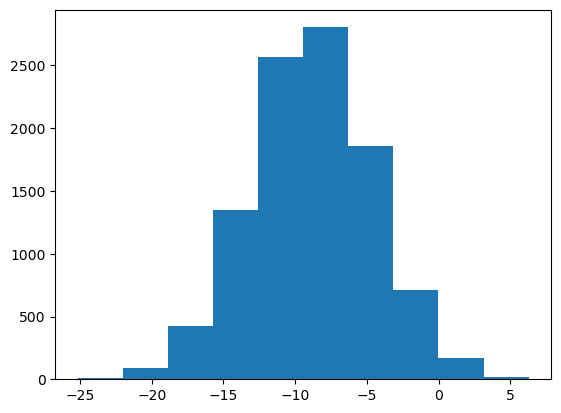

In [46]:
N_antenna = 10
constraint = "0025"   # Note: 0.00000025 = "5e-07"
f = h5py.File(f"/home/dbarker7752/21_cm_group/Exotic_Models_Data/expected_distro_vs_Lambda_extract_{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation","r")
    # f.attrs["Noise Value"] = N_antenna
    # f.create_dataset("chi squared",data=master_chi_squared_array)
    # f.create_dataset("psi squared",data=master_psi_squared_array)
    # f.create_dataset("term number",data=master_term_number_array)
Bayesian_evidence = np.array(f["Bayesian evidence"])
    # f.create_dataset("chi squared CDM",data=master_chi_squared_array_CDM)
    # f.create_dataset("psi squared CDM",data=master_psi_squared_array_CDM)
    # f.create_dataset("term number CDM",data=master_term_number_array_CDM)
Bayesian_evidence_CDM = np.array(f["Bayesian evidence CDM"])
    # f.close()

log_diff = Bayesian_evidence-Bayesian_evidence_CDM
plt.hist(log_diff)
print(log_diff.mean())
print(log_diff.std())

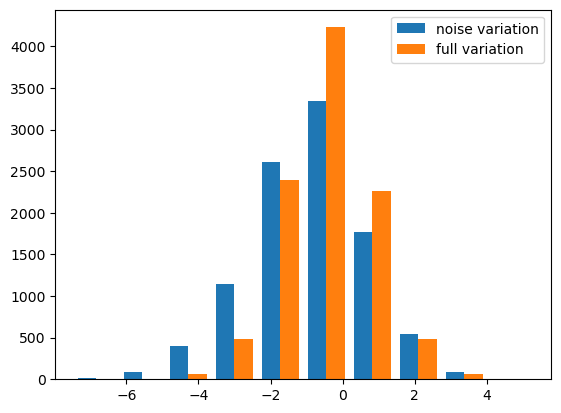

In [43]:
plt.hist([log_diff_base,log_diff],label=["noise variation","full variation"])
plt.legend()

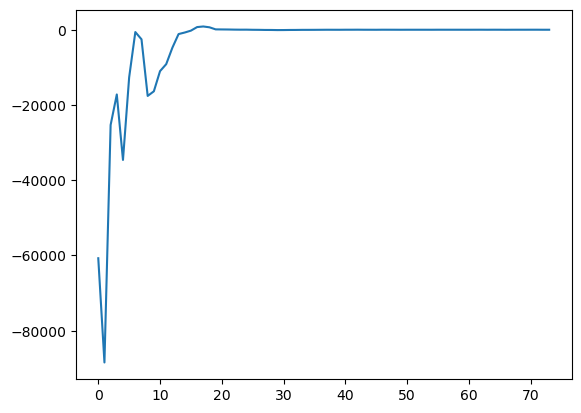

In [64]:
plt.plot(master_evidence_array[0][1:]-master_evidence_array_CDM[0][1:])

In [65]:
master_evidence_array[0][1:]-master_evidence_array_CDM[0][1:]

array([-6.07305848e+04, -8.84362128e+04, -2.53104953e+04, -1.72002908e+04,
       -3.45982014e+04, -1.26490121e+04, -6.08991946e+02, -2.53889820e+03,
       -1.75883091e+04, -1.63569520e+04, -1.10018664e+04, -9.13689614e+03,
       -4.76609720e+03, -1.14490400e+03, -7.31827132e+02, -2.33099007e+02,
        7.13818846e+02,  8.73133256e+02,  6.54300351e+02,  1.03874617e+02,
        8.50016256e+01,  6.94671878e+01,  3.80796247e+01,  2.17783665e+01,
        2.58708595e+01, -6.45193463e+00, -1.98244218e+01, -5.04281455e+01,
       -5.48529570e+01, -8.38485256e+01, -7.62602766e+01, -5.44788667e+01,
       -4.74692027e+01, -2.60563763e+01, -2.48070190e+01, -1.82596808e+01,
       -7.67971540e+00,  4.10843339e+00, -4.62553861e-01, -3.06393371e+00,
        9.29373353e+00,  9.81661352e+00,  1.78526246e+01,  5.72782053e+00,
        3.01662713e+00, -1.55677774e+00,  1.28593229e+01,  9.72793834e+00,
        7.32547793e+00,  3.08212460e-01,  6.14444654e+00,  6.28978753e+00,
        5.38009994e+00,  

In [82]:
flattened_systematics_training_set = np.reshape(systematics_training_set, (len(systematics_training_set), -1))
temperatures_flat = data.flatten()
noise_level_flat = noise.flatten()
Ns = len(noise)      # grabs the number of correlated spectra you are using
names = ["systematics"]        # names of your bases
bases = [
TrainedBasis(
    training_set=flattened_systematics_training_set,
    num_basis_vectors=num_basis_vectors,
    error=noise_level_flat,
    expander=NullExpander(),
    mean_translation=True
)]
basis_sum = BasisSum(names,bases)
dimension = [{'systematics' : np.arange(1,75)}]
priors = {"systematics_prior" : bases[0].gaussian_prior} 
meta_fitter = MetaFitter(basis_sum, temperatures_flat, noise_level_flat, quantity, quantity.name, *dimension,**priors,verbose=False)      # creates the meta_fitter object, which is an essential Pylinex object
logZ_grid = meta_fitter["log_evidence"]

best_indices = np.unravel_index(
    np.argmax(logZ_grid),
    logZ_grid.shape
)

fitter = meta_fitter.fitter_from_indices(best_indices)

print("Best term numbers:", fitter.sizes)
print("Maximum log evidence:", fitter.log_evidence)
                                                            
num_systematics_terms = fitter.sizes["systematics"]                                                
bases_for_least_squares = [TrainedBasis(training_set=flattened_systematics_training_set,num_basis_vectors=num_systematics_terms,error=noise_level_flat, expander=NullExpander())] 
# plot for the signal extraction
pylinex_error = fitter.subbasis_channel_error("systematics")
radiometer_error = noise[0]
# plt.plot((fitter.subbasis_channel_mean("systematics")-temperatures_flat)/noise_level_flat,label = "residual fit mean",color="blue")
# print(f"systematic terms used: {num_systematics_terms}")
# print(f"reduced chi squared: {fitter.reduced_chi_squared}")
# print(f"reduced psi squared: {fitter.psi_squared}")
chi_squared = fitter.reduced_chi_squared
psi_squared = fitter.psi_squared
term_number = num_systematics_terms

Best term numbers: {'systematics': 41}
Maximum log evidence: -2591.374953992877


In [80]:
input_signal = fiducial_signal
static_monchrome_beam_simulation=py21cmsig.multi_spectra_simulation_run(frequencies,simulated_foreground_array_10LSTs,input_signal,N_antenna,dnu,dt)
data=static_monchrome_beam_simulation[0]
noise = static_monchrome_beam_simulation[5]
signal = static_monchrome_beam_simulation[1]

The MetaFitter chose 40 systematics terms based on Bayesian evidence maximization.
The MetaFitter chose 1 signal terms based on Bayesian evidence maximization.
Maximum log evidence: -2588.4180508854415
0.9198108638198133 Chi Squared
0.7431189946422251 Psi Squared


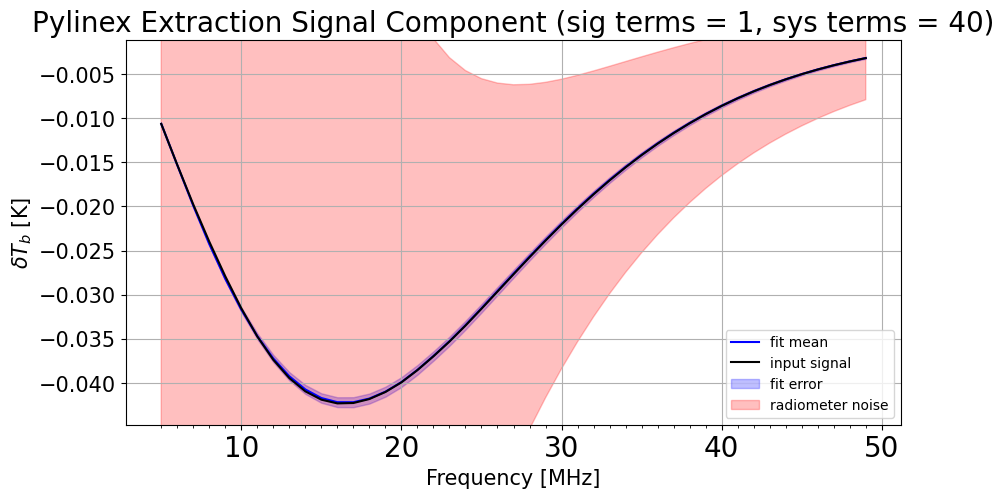

In [81]:
verbose=True
plot=True
signal = fiducial_signal
test_extraction_static_monochrome_LCDM = pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="log_evidence",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                        num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1)



The MetaFitter chose 74 systematics terms based on DIC minimization.
The MetaFitter chose 2 signal terms based on DIC minimization.
1.2127838039447396 Chi Squared
1.0865149679732409 Psi Squared


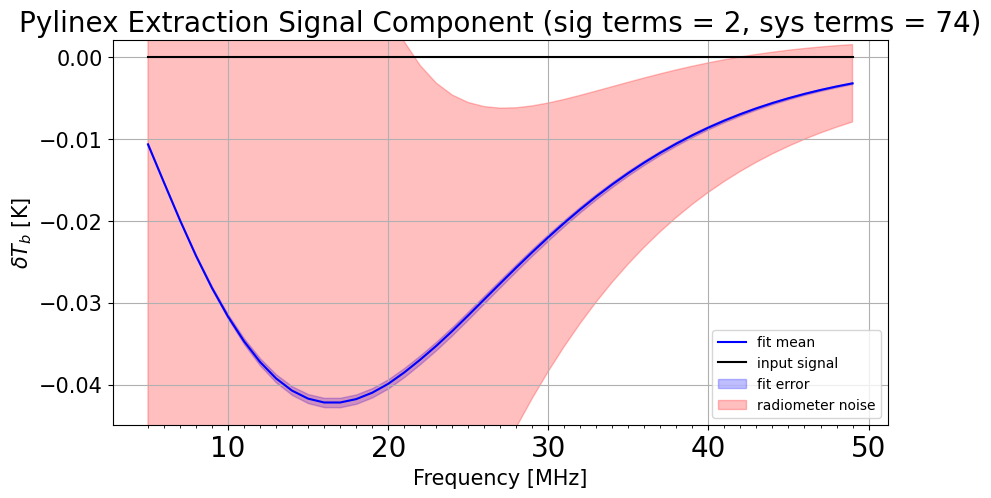

In [38]:
verbose=True
plot=True
test_extraction_static_monochrome_LCDM = pylinex_extraction(systematics_training_set,signal_training_set,data,noise,signal,frequencies,IC="DIC",verbose=verbose,plot=plot,plot_residual=False,num_basis_vectors=num_basis_vectors,num_sys_vectors = num_sys_vectors, \
                        num_sig_vectors = num_sig_vectors, title = "Pylinex Extraction", ignore_IC = False,ylim=None,man_sys_terms=manual_systematics_terms,man_sig_terms=manual_signal_terms,man_sys_terms_lower=0,man_sig_terms_lower=0,multi_spectra=True,priors=True,covariance_expansion_factor=1)



In [46]:
logZ_grid = meta_fitter["log_evidence"]

delta_logZ = np.abs(logZ_grid - np.max(logZ_grid))

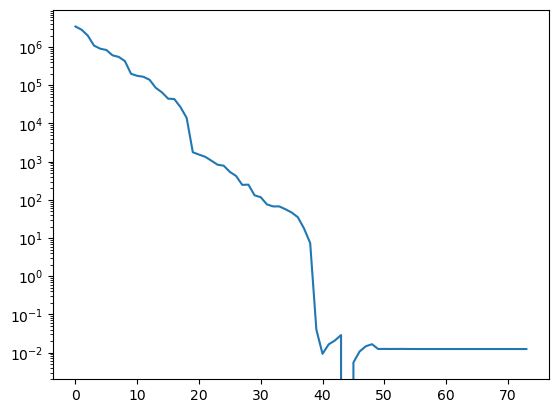

In [47]:
plt.plot(delta_logZ)
plt.yscale("log")

(-10.0, 0.1)

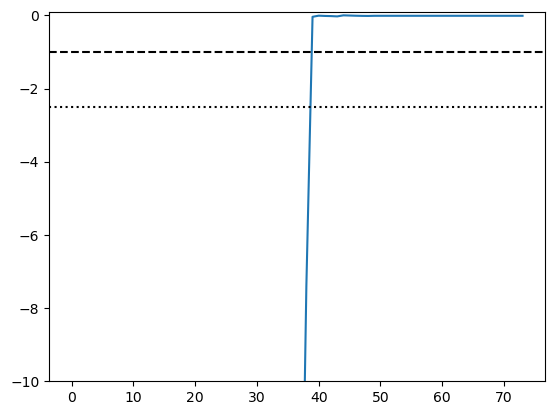

In [51]:
delta_logZ = logZ_grid - np.max(logZ_grid)

plt.plot( delta_logZ)
plt.axhline(-1, ls="--", color="black")
plt.axhline(-2.5, ls=":", color="black")
plt.ylim(-10, 0.1)

### Plot of Percent Detections $\Delta \ln Z$ < -5 for Multiple Prior Levels

Foreground uncertainty = 1% : P_det = 81.96%
Foreground uncertainty = 0.1% : P_det = 97.89%
Foreground uncertainty = 0.01% : P_det = 99.95%
Foreground uncertainty = 0.001% : P_det = 100.00%
Foreground uncertainty = 0.0001% : P_det = 100.00%


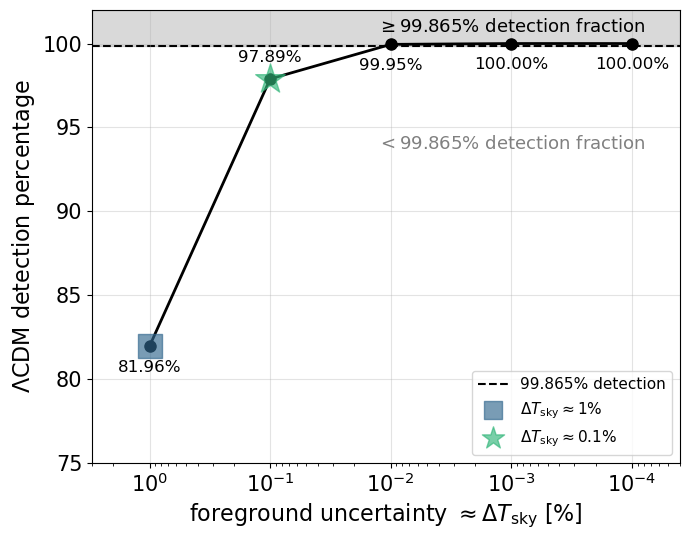

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import h5py


# ======================================================
# USER INPUTS
# ======================================================

N_antenna = 10

# Conservative case removed
constraint_suffixes = [
    "0025",
    "00025",
    "5e-05",
    "5e-06",
    "5e-07"
]

# Actual Delta beta_r values corresponding to the files
constraint_values = np.array([
    0.0025/0.0025,
    0.00025/0.0025,
    0.000025/0.0025,
    0.0000025/0.0025,
    0.00000025/0.0025
])

# Convert to percent
foreground_uncertainty = constraint_values

# Robust Lambda-CDM detection threshold
detection_threshold = -5

# Gaussian-equivalent one-sided 3-sigma detection fraction
three_sigma_fraction = 99.865


# ======================================================
# LOAD DATA AND CALCULATE DETECTION PERCENTAGE
# ======================================================

detection_percentages = []

for constraint in constraint_suffixes:

    filename = (
        "/home/dbarker7752/21_cm_group/Exotic_Models_Data/"
        f"expected_distro_vs_Lambda_extract_"
        f"{N_antenna}ants_{constraint}_Bayesian_10k_fullvariation"
    )

    with h5py.File(filename, "r") as f:

        foreground_logZ = np.array(
            f["Bayesian evidence"]
        )

        lambdaCDM_logZ = np.array(
            f["Bayesian evidence CDM"]
        )

    # --------------------------------------------------
    # Sign convention:
    #
    # Delta ln Z = ln Z_FG - ln Z_FG+LCDM
    #
    # Therefore Delta ln Z <= -5 robustly favors
    # foreground + LambdaCDM.
    # --------------------------------------------------

    delta_logZ = foreground_logZ - lambdaCDM_logZ

    detection_percentage = (
        100.0 * np.mean(
            delta_logZ <= detection_threshold
        )
    )

    detection_percentages.append(
        detection_percentage
    )


detection_percentages = np.array(
    detection_percentages
)


# ======================================================
# PRINT RESULTS
# ======================================================

for uncertainty, percentage in zip(
    foreground_uncertainty,
    detection_percentages
):

    print(
        f"Foreground uncertainty = {uncertainty:.6g}% : "
        f"P_det = {percentage:.2f}%"
    )


# ======================================================
# FIGURE
# ======================================================

plt.figure(
    figsize=(7, 5.5)
)

plt.xscale("log")

# Reverse x-axis:
# larger foreground uncertainty on left,
# tighter foreground knowledge on right
plt.xlim(
    3,
    0.00004
)

plt.ylim(
    75,
    102
)


# ======================================================
# DETECTION REGIME SHADING
# ======================================================

# Below 99.865%: <99.865% detection region
# plt.axhspan(
#     75,
#     three_sigma_fraction,
#     color="dimgray",
#     alpha=0.2,
#     zorder=0
# )

# Above 99.865%: >=99.865% detection region
plt.axhspan(
    three_sigma_fraction,
    102,
    color="black",
    alpha=0.15,
    zorder=0
)

# ======================================================
# DETECTION FRACTION CURVE
# ======================================================

plt.plot(
    foreground_uncertainty,
    detection_percentages,
    marker="o",
    markersize=8,
    color="black",
    linewidth=2,
    zorder=3,
)


# ======================================================
# PERCENTAGE LABELS
# ======================================================

for i, (x, y) in enumerate(zip(
    foreground_uncertainty,
    detection_percentages
)):

    # Put second point above; all others below
    if i == 1:
        offset = (0, 10)
        vertical_alignment = "bottom"
    else:
        offset = (0, -10)
        vertical_alignment = "top"

    plt.annotate(
        f"{y:.2f}%",
        xy=(x, y),
        xytext=offset,
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
        fontsize=12,
        color="black",
        zorder=6
    )


# ======================================================
# 3-SIGMA BENCHMARK
# ======================================================

plt.axhline(
    three_sigma_fraction,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label=r"99.865% detection",
    zorder=1
)


# ======================================================
# HIGHLIGHT NAMED FOREGROUND CASES
# ======================================================

marker_size = 300

# Optimistic = 0.25%
plt.scatter(
    foreground_uncertainty[0],
    detection_percentages[0],
    s=marker_size,
    marker="s",
    label=r"$\Delta T_{\rm sky} \approx 1\%$",
    color=OFG_color,
    alpha=0.65,
    zorder=5
)

# Overlap-Minimized = 0.025%
plt.scatter(
    foreground_uncertainty[1],
    detection_percentages[1],
    s=500,
    marker="*",
    label=r"$\Delta T_{\rm sky} \approx 0.1\%$",
    color=MFG_color,
    alpha=0.65,
    zorder=5
)


# ======================================================
# DETECTION-REGIME LABELS
# ======================================================

plt.text(
    0.001,
    94,
    r"$<99.865\%$ detection fraction",
    fontsize=13,
    ha="center",
    va="center",
    color="gray"
)

plt.text(
    0.001,
    101,
    r"$\geq99.865\%$ detection fraction",
    fontsize=13,
    ha="center",
    va="center",
    color=fiducial_color
)


# ======================================================
# STYLING
# ======================================================

plt.yticks(
    size=15
)

plt.xticks(
    size=15
)

plt.ylabel(
    r"$\Lambda$CDM detection percentage",
    fontsize=16
)

plt.xlabel(
    r"foreground uncertainty $\approx \Delta T_{\rm sky}$ [%]",
    fontsize=16
)

plt.grid(
    alpha=0.35
)

plt.legend(
    fontsize=11,
    markerscale=0.75,
    loc="lower right"
)

plt.tight_layout()

plt.show()

### Plot of Percent Detection $\Delta \ln Z$ < -5 for Multiple Noise Levels


 $\Delta T_{\rm sky}\approx20\%$
N_ant =   10, noise = 10.0000, P_det = 0.06%
N_ant =   25, noise = 25.0000, P_det = 0.77%
N_ant =  100, noise = 100.0000, P_det = 37.52%
N_ant =  250, noise = 250.0000, P_det = 86.59%
N_ant = 1000, noise = 1000.0000, P_det = 100.00%

 $\Delta T_{\rm sky}\approx1\%$
N_ant =   10, noise = 10.0000, P_det = 81.96%
N_ant =   25, noise = 25.0000, P_det = 99.36%
N_ant =  100, noise = 100.0000, P_det = 100.00%
N_ant =  250, noise = 250.0000, P_det = 100.00%
N_ant = 1000, noise = 1000.0000, P_det = 100.00%

 $\Delta T_{\rm sky}\approx0.1\%$
N_ant =   10, noise = 10.0000, P_det = 97.89%
N_ant =   25, noise = 25.0000, P_det = 99.95%
N_ant =  100, noise = 100.0000, P_det = 100.00%
N_ant =  250, noise = 250.0000, P_det = 100.00%
N_ant = 1000, noise = 1000.0000, P_det = 100.00%


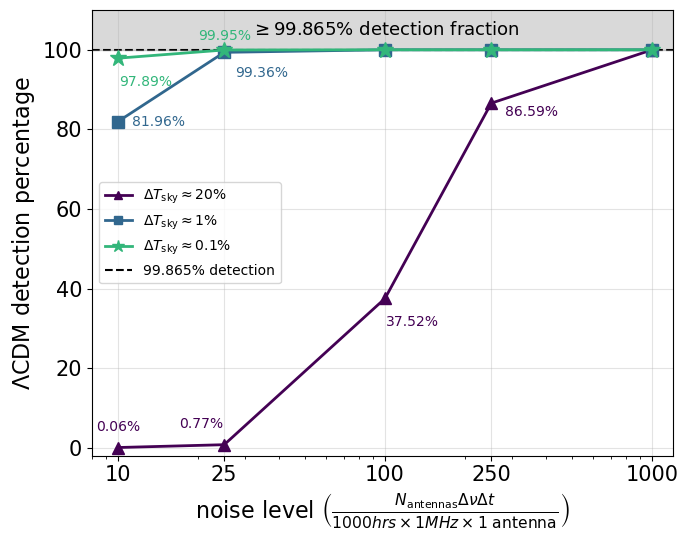

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import h5py


# ======================================================
# USER INPUTS
# ======================================================

N_antenna_values = np.array([
    10,
    25,
    100,
    250,
    1000
])

# ------------------------------------------------------
# Foreground cases
#
# These should correspond to:
#
# 0.05    -> Delta T_sky ~ 20%
# 0.0025  -> Delta T_sky ~ 1%
# 0.00025 -> Delta T_sky ~ 0.1%
# ------------------------------------------------------

constraint_suffixes = [
    "05",
    "0025",
    "00025"
]

foreground_labels = [
    r"$\Delta T_{\rm sky}\approx20\%$",
    r"$\Delta T_{\rm sky}\approx1\%$",
    r"$\Delta T_{\rm sky}\approx0.1\%$"
]

colors = [
    CFG_color,
    OFG_color,
    MFG_color
]

markers = [
    "^",
    "s",
    "*"
]

marker_sizes = [
    8,
    8,
    12
]


# ======================================================
# NORMALIZED NOISE LEVEL
# ======================================================

# Radiometer noise scales approximately as
# sigma ~ 1 / sqrt(N_antenna).
#
# Normalize to the N_antenna = 10 case so that:
#
# N_ant = 10   -> noise level = 1
# N_ant = 25   -> noise level ~ 0.632
# N_ant = 100  -> noise level ~ 0.316
# etc.

noise_levels = N_antenna_values


# ======================================================
# BAYESIAN DETECTION SETTINGS
# ======================================================

# Robust Lambda-CDM detection threshold
detection_threshold = -5

# One-sided Gaussian-equivalent 3-sigma detection fraction
three_sigma_fraction = 99.865


# ======================================================
# LOAD DATA AND CALCULATE DETECTION PERCENTAGES
# ======================================================

# Shape:
#
# [foreground case, noise level]
#
# -> (3, 5)

detection_percentages = np.zeros(
    (
        len(constraint_suffixes),
        len(N_antenna_values)
    )
)


for i_constraint, constraint in enumerate(
    constraint_suffixes
):

    for i_noise, N_antenna in enumerate(
        N_antenna_values
    ):

        filename = (
            "/home/dbarker7752/21_cm_group/"
            "Exotic_Models_Data/"
            f"expected_distro_vs_Lambda_extract_"
            f"{N_antenna}ants_{constraint}_"
            f"Bayesian_10k_fullvariation"
        )

        with h5py.File(filename, "r") as f:

            foreground_logZ = np.array(
                f["Bayesian evidence"]
            )

            lambdaCDM_logZ = np.array(
                f["Bayesian evidence CDM"]
            )


        # --------------------------------------------------
        # Sign convention:
        #
        # Delta ln Z
        # =
        # ln Z_FG - ln Z_FG+LCDM
        #
        # Therefore:
        #
        # Delta ln Z <= -5
        #
        # robustly favors foreground + LambdaCDM.
        # --------------------------------------------------

        delta_logZ = (
            foreground_logZ
            - lambdaCDM_logZ
        )


        detection_percentage = (
            100.0
            * np.mean(
                delta_logZ
                <= detection_threshold
            )
        )


        detection_percentages[
            i_constraint,
            i_noise
        ] = detection_percentage


# ======================================================
# PRINT RESULTS
# ======================================================

for label, percentages in zip(
    foreground_labels,
    detection_percentages
):

    print("\n", label)

    for N_antenna, noise, percentage in zip(
        N_antenna_values,
        noise_levels,
        percentages
    ):

        print(
            f"N_ant = {N_antenna:4d}, "
            f"noise = {noise:.4f}, "
            f"P_det = {percentage:.2f}%"
        )


# ======================================================
# FIGURE
# ======================================================

fig, ax = plt.subplots(
    figsize=(7, 5.5)
)


# ======================================================
# DETECTION REGIME SHADING
# ======================================================

ax.axhspan(
    three_sigma_fraction,
    115,
    color="black",
    alpha=0.15,
    zorder=0
)


# ======================================================
# DETECTION FRACTION CURVES
# ======================================================

for percentages, label, color, marker, size in zip(
    detection_percentages,
    foreground_labels,
    colors,
    markers,
    marker_sizes
):

    ax.plot(
        noise_levels,
        percentages,
        marker=marker,
        markersize=size,
        color=color,
        linewidth=2,
        label=label,
        zorder=3
    )


# ======================================================
# PERCENTAGE LABELS
# ======================================================

# Individual label positions are specified as
# (x offset, y offset) in points.
#
# None means that the percentage label is not shown.
#
# Order of points:
# N_ant = [10, 25, 100, 250, 1000]

label_positions = [

    # --------------------------------------------------
    # Purple: Delta T_sky ~ 20%
    # --------------------------------------------------
    [
        (0, 10),     # 10
        (-0.5, 10),     # 25
        (1, -12),     # 100
        (10, -1),      # 250: move 86.59% to right of marker
        None          # 1000: no label
    ],

    # --------------------------------------------------
    # Blue: Delta T_sky ~ 1%
    # --------------------------------------------------
    [
        (10, 0),      # 10: move label to right of marker
        (8, -10),     # 25: bottom-right to avoid blue line
        None,     # 100: directly below marker
        None,     # 250: directly below marker
        None          # 1000: no label
    ],

    # --------------------------------------------------
    # Green: Delta T_sky ~ 0.1%
    # --------------------------------------------------
    [
        (1, -12),     # 10: slightly right, away from plot edge
        (0, 5),      # 25: above marker
        None,     # 100: below blue percentage label
        None,     # 250: below blue percentage label
        None          # 1000: no label
    ]
]


for percentages, color, positions in zip(
    detection_percentages,
    colors,
    label_positions
):

    for x, y, position in zip(
        noise_levels,
        percentages,
        positions
    ):

        # Skip labels explicitly marked as None
        if position is None:
            continue

        x_offset, y_offset = position

        # Horizontal alignment
        if x_offset > 0:
            horizontal_alignment = "left"
        elif x_offset < 0:
            horizontal_alignment = "right"
        else:
            horizontal_alignment = "center"

        # Vertical alignment
        if y_offset > 0:
            vertical_alignment = "bottom"
        elif y_offset < 0:
            vertical_alignment = "top"
        else:
            vertical_alignment = "center"

        ax.annotate(
            f"{y:.2f}%",
            xy=(x, y),
            xytext=(x_offset, y_offset),
            textcoords="offset points",
            ha=horizontal_alignment,
            va=vertical_alignment,
            fontsize=10,
            color=color,
            zorder=6
        )
# ======================================================
# 3-SIGMA BENCHMARK
# ======================================================

ax.axhline(
    three_sigma_fraction,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label=r"99.865% detection",
    zorder=1
)


# ======================================================
# DETECTION-REGIME LABELS
# ======================================================

# ax.text(
#     100,
#     94,
#     r"$<99.865\%$ detection fraction",
#     fontsize=13,
#     ha="center",
#     va="center",
#     color="gray"
# )

ax.text(
    100,
    105,
    r"$\geq99.865\%$ detection fraction",
    fontsize=13,
    ha="center",
    va="center",
    color="black"
)


# ======================================================
# STYLING
# ======================================================


ax.set_ylim(
    -2,
    110
)

ax.set_xscale("log")

ax.set_xlim(
    8,
    1200
)

ax.set_xticks(
    N_antenna_values
)

ax.set_xticklabels([
    "10",
    "25",
    "100",
    "250",
    "1000"
])

ax.set_ylabel(
    r"$\Lambda$CDM detection percentage",
    fontsize=16
)

ax.set_xlabel(
    r"noise level $\left(\frac{N_{\rm antennas} \Delta \nu \Delta t }{1000 hrs \times 1MHz \times 1 \ {\rm antenna}}\right)$",
    fontsize=16
)

ax.tick_params(
    axis="both",
    labelsize=15
)

ax.grid(
    alpha=0.35
)

ax.legend(
    fontsize=10,
    markerscale=0.75,
    loc="center left"
)

plt.tight_layout()
plt.show()